# Regression and Variational Autoencoders for DNA Methylation–Based Cell Type Estimation


## Introduction

This project looks at the DNA fragments that circulate in the blood. These fragments come from many different cell types in the body. When tissues are damaged or diseased, they release more DNA than usual, so the mix of DNA in the blood changes. By figuring out which cell types the DNA comes from, we can get an early picture of tissue health (as an example in a [COVID study](https://doi.org/10.1172/jci.insight.147610), and in [cancer](https://doi.org/10.1038/nrc.2017.7). This could become a powerful, non-invasive way to detect and monitor diseases—such as cancer—using nothing more than a routine blood test.

Traditionally, researchers study what types of cells are present in a tissue sample by using methods like staining cells under a microscope, sorting them, or sequencing single cells. Another way is to look at [DNA methylation](https://www.sciencedirect.com/topics/biochemistry-genetics-and-molecular-biology/methylome), which acts like a chemical “fingerprint” that is unique to each cell type. By reading these fingerprints, we can estimate how much DNA comes from each cell type in a mixed sample, such as blood.


## Methods

### Regression-based

I first applied established regression-based deconvolution methods to estimate cell type proportions from bulk DNA methylation data. These methods assume that the observed methylation profile is a weighted mixture of reference profiles from individual cell types. By solving for the weights, I obtain the estimated cell type fractions. Specifically, I tested **non-negative least squares (NNLS)**, constrained optimization (enforcing weights to sum to one), **ridge regression**, **lasso regression**, and **elastic net** regression. Each method was applied to simulated datasets generated with known ground-truth proportions, allowing us to directly evaluate accuracy. I compared performance across multiple conditions, including different levels of noise, numbers of CpGs, and varying similarity between cell types. This design follows the benchmarking review by de Ridder et al. [\[DOI: 10.1038/s41467-024-48466-z\]](https://doi.org/10.1038/s41467-024-48466-z).


### Deep learning - variational autoencoder

In addition to regression approaches, I implemented a **variational autoencoder (VAE)** with an additional output head to predict cell type proportions. The VAE is trained to reconstruct CpG methylation profiles while simultaneously learning to predict the proportion of each cell type in the mixture. The encoder maps input methylation profiles into a latent representation, from which both the reconstructed profiles and predicted proportions are derived. Training was performed using a combined loss function consisting of (i) reconstruction error, (ii) supervised proportion error, and (iii) a regularization term (KL divergence). This approach allows the model to capture complex, non-linear patterns in methylation data that may not be well described by regression models. Performance was assessed by comparing predicted proportions against the known ground truth using mean absolute error (MAE), alongside visualization of reconstructed vs. true profiles. The approach was inspired by a published model called [MethylNet by Levy et al., 2020](https://doi.org/10.1186/s12859-020-3443-8).

### Semi-supervised NMF

To further improve performance, I implemented **semi-supervised non-negative matrix factorization (ssNMF)**.  
Unlike purely unsupervised NMF, ssNMF incorporates prior knowledge from reference methylation profiles by anchoring part of the factorization to known cell type signatures.  

- This helps guide the decomposition toward biologically meaningful solutions.  
- The reference matrix constrains the model, while the sample-specific factors remain flexible to capture variability.  
- As a result, ssNMF can balance interpretability with robustness against noise and collinearity.  

In practice, ssNMF produced the most accurate estimates, outperforming both regression-based methods and the VAE under noisy and complex conditions.

### Transformer

Finally, I implemented a tiny **Transformer-based model** for deconvolution, treating each CpG region as a token in a sequence. Each token was represented by its region identity (learned embedding) and methylation beta value (linear projection). The model uses a transformer encoder with self-attention layers to capture dependencies between CpG regions across the genome. The encoder outputs are pooled to produce a sample-level embedding, which is passed through a feed-forward network with softmax activation to predict cell type proportions. In addition to predicting proportions, the model learns a basis matrix \(W\) (CpGs × cell types) that is initialized from the reference matrix \(R\) and regularized to remain close to it (anchor loss). The overall loss function combines reconstruction error (\(\|Y - WH\|^2\)) and anchoring penalty (\(\|W - R\|^2\)), with gradients jointly updating the Transformer parameters and \(W\). Training was performed with AdamW optimization, mini-batching, and random subsampling of CpGs to improve efficiency. This architecture is designed to integrate CpG-level sequence context while leveraging prior reference information, providing a flexible hybrid between regression and NMF approaches.



## Results

In [1]:
# === Standard scientific stack ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Optimization & linear models (regression baselines) ===
from scipy.optimize import nnls, minimize
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.model_selection import train_test_split

# === PyTorch (VAE) ===
import torch
import torch.nn as nn
import torch.nn.functional as F

# === reproducibility ===
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(7)
np.random.seed(7)

### Simulate input data

In [ ]:
# =========================
# Simulate data
# =========================

# ---------- simulation helpers ----------
def simulate_hard(n_cpgs=200, n_celltypes=6, n_samples=4, noise_sd=0.07, seed=123):
    rng = np.random.default_rng(seed)
    # Start from a low-rank-ish base to induce collinearity between cell types
    base = rng.uniform(0.1, 0.9, size=(n_cpgs, 2))
    R = np.zeros((n_cpgs, n_celltypes))
    for k in range(n_celltypes):
        a, b = rng.uniform(0.2, 1.0, size=2)
        R[:, k] = np.clip(a*base[:, 0] + b*base[:, 1] + rng.normal(0, 0.05, n_cpgs), 0, 1)

    # True proportions, some samples deliberately sparse
    W_true = np.zeros((n_celltypes, n_samples))
    for j in range(n_samples):
        if j % 2 == 0:
            # sparse mix
            idx = rng.choice(n_celltypes, size=2, replace=False)
            w = np.zeros(n_celltypes); w[idx] = rng.uniform(0.05, 1.0, size=2); w /= w.sum()
        else:
            w = rng.dirichlet(np.ones(n_celltypes))
        W_true[:, j] = w

    # Mixtures + noise
    Y = np.clip(R @ W_true + rng.normal(0, 
                                        noise_sd, 
                                        size=(n_cpgs, n_samples)), 
                                        0, 1)

    # Simulate slight reference mismatch (batch effect / platform diff)
    R_ref = np.clip(R + rng.normal(0, 0.03, size=R.shape), 0, 1)

    cpgs = [f"cg{i:06d}" for i in range(1, n_cpgs+1)]
    celltypes = [f"CellType_{chr(65+i)}" for i in range(n_celltypes)]
    samples = [f"Sample_{i+1}" for i in range(n_samples)]

    ref_df = pd.DataFrame(R_ref, columns=celltypes, index=cpgs).reset_index().rename(columns={"index":"cpg"})
    mix_df = pd.DataFrame(Y, columns=samples, index=cpgs).reset_index().rename(columns={"index":"cpg"})
    truth  = pd.DataFrame(W_true, index=celltypes, columns=samples)
    return ref_df, mix_df, truth

def align_by_cpg(ref_df, mix_df):
    common = sorted(set(ref_df.cpg) & set(mix_df.cpg))
    R = ref_df.set_index("cpg").loc[common]
    Y = mix_df.set_index("cpg").loc[common]
    return R, Y

# =========================
# RUN SIMULATION (shared for both regression & VAE)
# =========================
ref_df, mix_df, truth = simulate_hard(n_cpgs=2000, 
                                      n_celltypes=6, 
                                      n_samples=200, 
                                      noise_sd=0.07, 
                                      seed=123)
ref_aln, mix_aln = align_by_cpg(ref_df, mix_df)

# Ensure truth index/columns order match ref/mix for perfect alignment
truth = truth.reindex(index=ref_aln.columns, columns=mix_aln.columns)


### Run regression-based deconvolution

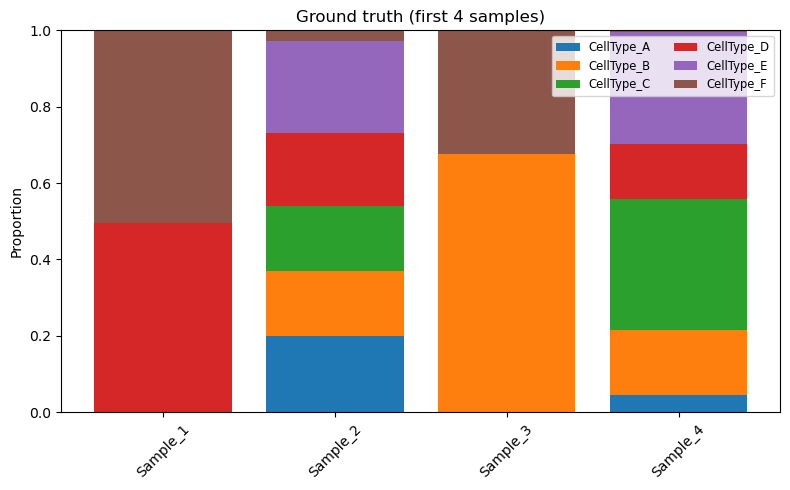

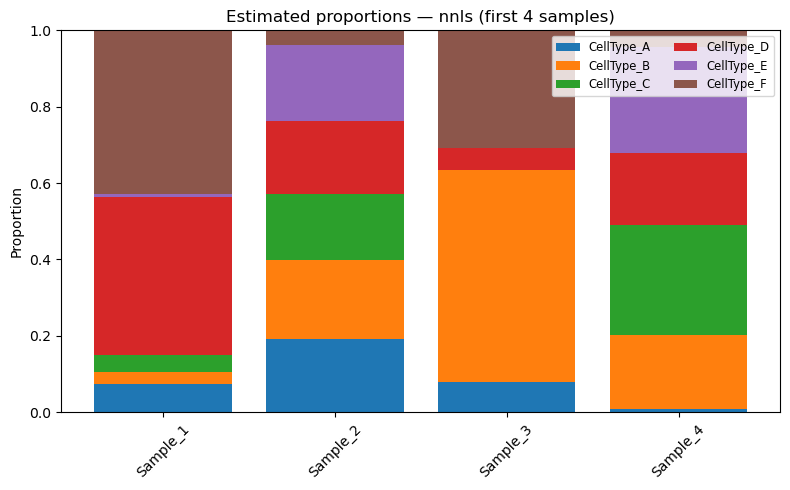

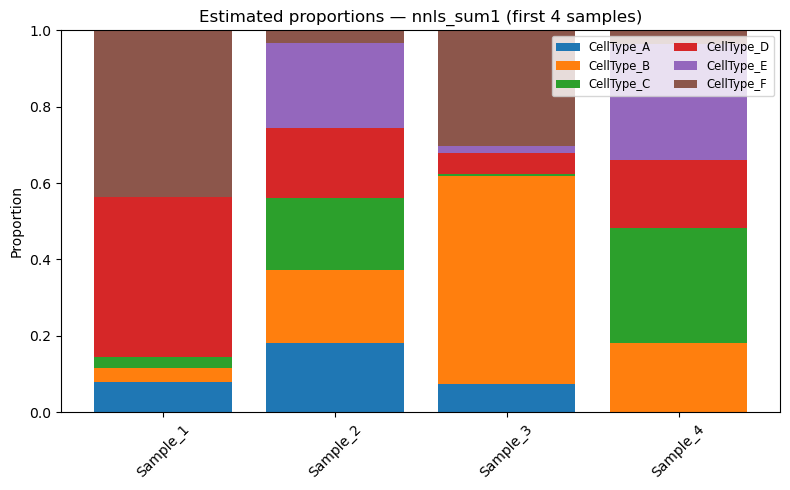

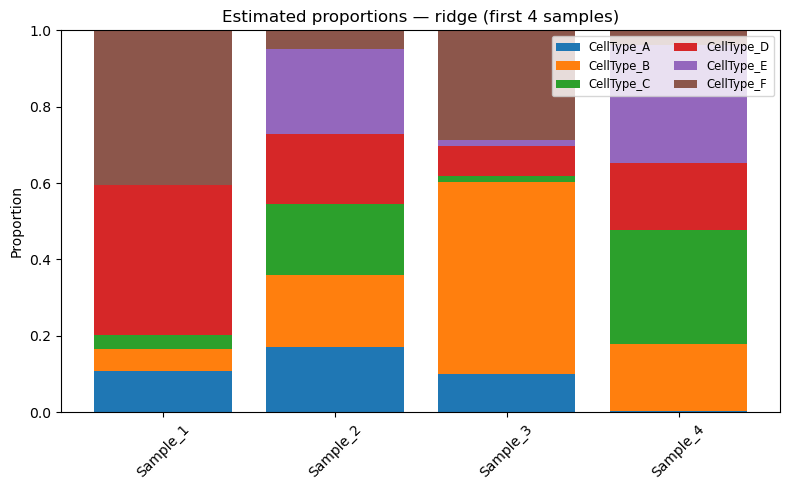

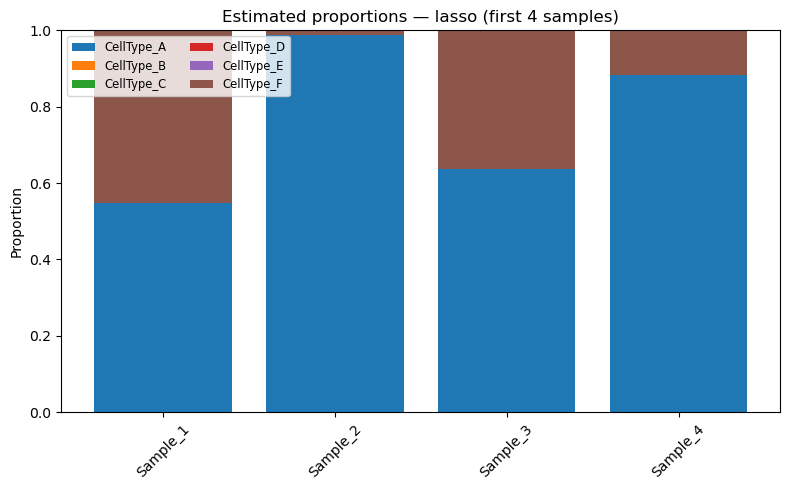

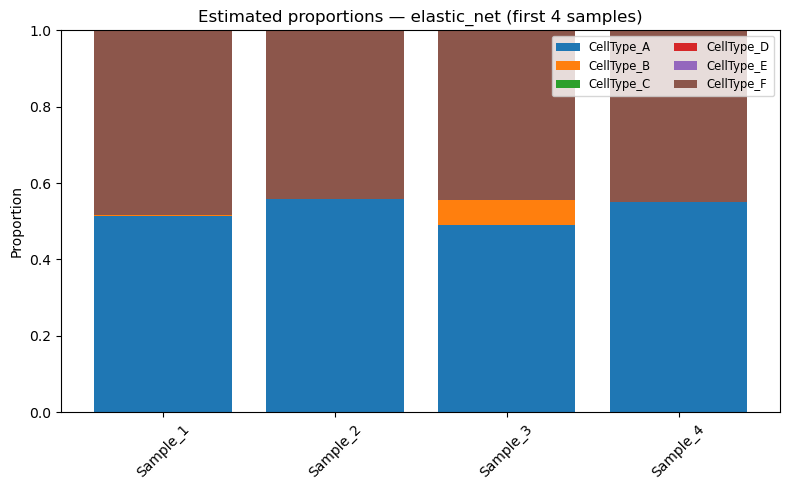

In [3]:
# =========================
# PART 1: REGRESSION DECONVOLUTION (plot only first 4 samples)
# =========================

# ---------- solvers ----------
def solve_nnls(R, y, sum_to_one=True):
    w, _ = nnls(R, y)
    if sum_to_one and w.sum() > 0:
        w = w / w.sum()
    return w

def solve_nnls_sum1(R, y):
    n = R.shape[1]
    bounds = [(0, None)] * n
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    def obj(w):
        r = R @ w - y
        return float(r @ r)
    res = minimize(obj, x0=np.ones(n)/n, bounds=bounds, constraints=cons, method="SLSQP")
    return res.x if res.success else solve_nnls(R, y, sum_to_one=True)

def solve_ridge_nonneg(R, y, alpha=1.0, sum_to_one=True):
    n = R.shape[1]
    bounds = [(0, None)] * n
    cons = ({"type":"eq", "fun": lambda w: np.sum(w) - 1.0},) if sum_to_one else ()
    def obj(w):
        r = R @ w - y
        return float(r @ r + alpha * (w @ w))
    res = minimize(obj, x0=np.ones(n)/n, bounds=bounds, constraints=cons, method="SLSQP")
    return res.x if res.success else solve_nnls(R, y, sum_to_one=sum_to_one)

def solve_lasso_pos(R, y, alpha=0.05, sum_to_one=True):
    model = Lasso(alpha=alpha, positive=True, fit_intercept=False, max_iter=10000)
    model.fit(R, y)
    w = model.coef_
    if sum_to_one and w.sum() > 0:
        w = w / w.sum()
    return w

def solve_elastic_pos(R, y, alpha=0.08, l1_ratio=0.7, sum_to_one=True):
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, positive=True, fit_intercept=False, max_iter=20000)
    model.fit(R, y)
    w = model.coef_
    if sum_to_one and w.sum() > 0:
        w = w / w.sum()
    return w

def deconvolve_all(ref_aln, mix_aln, sum_to_one=True):
    R = ref_aln.values
    celltypes = list(ref_aln.columns)
    samples = list(mix_aln.columns)
    out = {m: pd.DataFrame(0.0, index=celltypes, columns=samples)
           for m in ["nnls","nnls_sum1","ridge","lasso","elastic_net"]}
    for s in samples:
        y = mix_aln[s].values
        out["nnls"][s]        = solve_nnls(R, y, sum_to_one=sum_to_one)
        out["nnls_sum1"][s]   = solve_nnls_sum1(R, y)
        out["ridge"][s]       = solve_ridge_nonneg(R, y, alpha=1.0, sum_to_one=sum_to_one)
        out["lasso"][s]       = solve_lasso_pos(R, y, alpha=0.05, sum_to_one=sum_to_one)
        out["elastic_net"][s] = solve_elastic_pos(R, y, alpha=0.08, l1_ratio=0.7, sum_to_one=sum_to_one)
    return out

# ---------- plotting ----------
def plot_stacked(W, title):
    samples = list(W.columns)
    celltypes = list(W.index)
    x = np.arange(len(samples))
    bottom = np.zeros(len(samples))
    plt.figure(figsize=(8, 5))
    for ct in celltypes:
        vals = W.loc[ct].values
        plt.bar(x, vals, bottom=bottom, label=ct)
        bottom += vals
    plt.xticks(x, samples, rotation=45)
    plt.ylim(0, 1)
    plt.ylabel("Proportion")
    plt.title(title)
    plt.legend(ncol=2, fontsize="small")
    plt.tight_layout()
    plt.show()

def proportion_errors(W_hat, W_true):
    e = (W_hat - W_true).abs()
    per_sample = e.mean(axis=0)
    overall = e.values.mean()
    return per_sample, overall


results = deconvolve_all(ref_aln, mix_aln, sum_to_one=True)

subset_samples = truth.columns[:4]  # first 4 samples

plot_stacked(truth[subset_samples], "Ground truth (first 4 samples)")
for method, dfw in results.items():
    plot_stacked(dfw[subset_samples], f"Estimated proportions — {method} (first 4 samples)")




In [4]:
# Optional: metrics table over all samples
# MAE: mean absolute error

def proportion_errors(W_hat, W_true):
    # MAE per sample and overall
    e = (W_hat - W_true).abs()
    per_sample = e.mean(axis=0)
    overall = e.values.mean()
    return per_sample, overall

errs = {}
for method, dfw in results.items():
    ps, overall = proportion_errors(dfw, truth)
    errs[method] = {"overall_MAE": overall, **{f"MAE_{c}": v for c, v in ps.items()}}
display(pd.DataFrame(errs).T.sort_values("overall_MAE"))


,overall_MAE,MAE_Sample_1,MAE_Sample_2,MAE_Sample_3,MAE_Sample_4,MAE_Sample_5,MAE_Sample_6,MAE_Sample_7,MAE_Sample_8,MAE_Sample_9,...,MAE_Sample_191,MAE_Sample_192,MAE_Sample_193,MAE_Sample_194,MAE_Sample_195,MAE_Sample_196,MAE_Sample_197,MAE_Sample_198,MAE_Sample_199,MAE_Sample_200
nnls_sum1,0.037753,0.047892,0.015180,0.050989,0.029262,0.069571,0.023280,0.049941,0.016097,0.044773,...,0.035415,0.026647,0.030937,0.052038,0.052500,0.013869,0.067811,0.051210,0.067801,0.030136
nnls,0.039715,0.052869,0.016619,0.045997,0.035402,0.069353,0.027329,0.052395,0.019172,0.047398,...,0.035262,0.026661,0.031705,0.043174,0.056480,0.013454,0.065991,0.052556,0.070176,0.030113
ridge,0.049747,0.067016,0.019433,0.069461,0.029886,0.087918,0.031672,0.069598,0.021492,0.065145,...,0.054973,0.032673,0.057106,0.057273,0.066343,0.017994,0.088164,0.055293,0.084590,0.039768
elastic_net,0.234674,0.171875,0.258111,0.203246,0.316455,0.306439,0.150303,0.324965,0.100888,0.169003,...,0.316807,0.190783,0.171111,0.284456,0.314476,0.220577,0.143395,0.256202,0.190938,0.273621
lasso,0.248058,0.182832,0.262646,0.225172,0.316455,0.333333,0.180386,0.333333,0.149720,0.158363,...,0.333333,0.241380,0.173024,0.284456,0.333333,0.224280,0.143395,0.273103,0.268477,0.287642


### Minimal MethylNet‑style VAE for toy methylation data (PyTorch)

What this does?
- Builds a VAE encoder/decoder for beta values.
- Adds a softmax head to predict cell‑type proportions (non‑negativity + sum‑to‑one baked in).
- Joint loss = reconstruction MSE + proportion MSE + small KL term.
- Trains on synthetic mixtures, prints losses and a test MAE for proportions.

This mirrors the spirit of MethylNet (VAE + downstream prediction) without its automation/CLI and rich hyperparameter tooling. For the full model (grid search, CLI, dataset helpers, interpretation utilities), see: BMC Bioinformatics (2020) and the GitHub/docs.

[MethylNet](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/s12859-020-3443-8#Sec12) can be used to perform classification, regression, and multi-output regression tasks via the prediction subroutine, which applies a transfer learning technique via the Python class MLPFinetuneVAE to fine-tune encoding layers of VAE model while simultaneously training a few appended hidden layers for prediction. [Code to the Methylnet models](https://github.com/Christensen-Lab-Dartmouth/MethylNet/blob/master/build/lib/methylnet/models.py).

In [5]:
# =========================
# PART 2: VAE on the SAME data
# =========================

# Prepare matrices
R = ref_aln.values.astype(np.float32)           # (p × k)
Y = mix_aln.values.astype(np.float32)           # (p × n)
X = Y.T                                         # (n × p)
T = truth.T.values.astype(np.float32)           # (n × k)

n_cpgs, n_celltypes = R.shape
n_samples = X.shape[0]
print("Shapes - X, T, R:", X.shape, T.shape, R.shape)

assert X.shape[0] == T.shape[0]
assert R.shape[0] == X.shape[1]
assert R.shape[1] == T.shape[1]

# Split train/test
X_train, X_test, T_train, T_test = train_test_split(X, T, test_size=0.2, random_state=0)

# Variational autoencoder with proportion head
class VAEProp(nn.Module):
    '''
    This VAE is trained on CpG methylation profiles (X) to simultaneously
    reconstruct CpGs (unsupervised) and
    predict cell type proportions (T) (supervised).
    The final output is the predicted proportions per sample, which can be compared against the ground truth using MAE.

                ┌──────────────────────────────────────────────────────────┐
                │                          ENCODER                         │
    x (CpGs)    │                                                          │
    (n_cpgs)--> │  enc1: Linear(n_cpgs → h1) → ReLU                        │
                │        (2000 → 1024)                                     │
                │  enc2: Linear(h1 → h2) → ReLU                            │
                │        (1024 → 256)                                      │
                │                                                          │
                │  mu:   Linear(h2 → latent_dim)     (256 → 32)            │
                │  logv: Linear(h2 → latent_dim)     (256 → 32)            │
                └──────────────────────────────────────────────────────────┘
                                        │
                                        │   reparameterize:
                                        │   z = mu + eps * exp(0.5*logv)
                                        ▼
                            z (latent code, size = latent_dim = 32)
                            ├───────────────────────────────┐
                            │                               │
                            │                               │
            ┌───────────────▼──────────────┐   ┌───────────▼────────────────┐
            │          DECODER             │   │       PROPORTION HEAD       │
            │                              │   │                              │
            │  dec1: Linear(32 → 256)→ReLU │   │  head1: Linear(32 → H)→ReLU │
            │  dec2: Linear(256 → 1024)→ReLU│  │         (H = max(64, 4*k))  │
            │  out : Linear(1024 → 2000)   │   │  head2: Linear(H → k)        │
            │  sigmoid(out) → x_hat (2000) │   │  softmax → p_hat (k classes) │
            └──────────────────────────────┘   └──────────────────────────────┘
                         │                                   │
                         │                                   │
                 recon loss (MSE)                    proportion loss (MSE)
                         │                                   │
                         └──────────────┬────────────────────┘
                                        │
                                KL term from (mu, logv)
                                        │
                           total loss = recon + λ_prop * prop + λ_KL * KL
    '''
    def __init__(self, in_dim, latent_dim=32, hidden=(1024, 256), n_classes=6, kl_weight=1e-4, prop_weight=2.0):
        super().__init__()
        self.kl_weight = kl_weight
        self.prop_weight = prop_weight
        h1, h2 = hidden

        # Encoder
        self.enc1 = nn.Linear(in_dim, h1)
        self.enc2 = nn.Linear(h1, h2)
        self.mu   = nn.Linear(h2, latent_dim)
        self.logv = nn.Linear(h2, latent_dim)

        # Decoder
        self.dec1 = nn.Linear(latent_dim, h2)
        self.dec2 = nn.Linear(h2, h1)
        self.out  = nn.Linear(h1, in_dim)

        # Proportion head
        self.head1 = nn.Linear(latent_dim, max(64, n_classes*4))
        self.head2 = nn.Linear(max(64, n_classes*4), n_classes)

    def encode(self, x):
        h = F.relu(self.enc1(x))
        h = F.relu(self.enc2(h))
        return self.mu(h), self.logv(h)

    def reparameterize(self, mu, logv):
        std = torch.exp(0.5 * logv)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.dec1(z))
        h = F.relu(self.dec2(h))
        return torch.sigmoid(self.out(h))

    def predict_prop(self, z):
        h = F.relu(self.head1(z))
        return F.softmax(self.head2(h), dim=-1)

    def forward(self, x):
        mu, logv = self.encode(x)
        z = self.reparameterize(mu, logv)
        x_hat = self.decode(z)
        p_hat = self.predict_prop(z)
        return x_hat, p_hat, mu, logv

    def loss_fn(self, x, x_hat, p_true, p_hat, mu, logv):
        recon = F.mse_loss(x_hat, x)
        sup   = F.mse_loss(p_hat, p_true)
        kl    = -0.5 * torch.mean(1 + logv - mu.pow(2) - logv.exp())
        return recon + self.prop_weight*sup + self.kl_weight*kl, recon, sup, kl


# Instantiate model + optimizer
model = VAEProp(in_dim=n_cpgs, latent_dim=32, hidden=(1024, 256),
                n_classes=n_celltypes, kl_weight=1e-4, prop_weight=2.0).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

# Data to tensors
Xtr = torch.from_numpy(X_train).to(DEVICE)
Ttr = torch.from_numpy(T_train).to(DEVICE)
Xte = torch.from_numpy(X_test).to(DEVICE)
Tte = torch.from_numpy(T_test).to(DEVICE)

# Training loop
batch = 64
epochs = 50
model.train()
history = {"loss": [], "recon": [], "sup": [], "kl": []}

for ep in range(1, epochs+1):
    perm = torch.randperm(Xtr.size(0), device=DEVICE)
    tot = {"loss":0.0, "recon":0.0, "sup":0.0, "kl":0.0}
    for i in range(0, Xtr.size(0), batch):
        idx = perm[i:i+batch]
        xb, tb = Xtr[idx], Ttr[idx]

        opt.zero_grad()
        x_hat, p_hat, mu, logv = model(xb)
        loss, recon, sup, kl = model.loss_fn(xb, x_hat, tb, p_hat, mu, logv)
        loss.backward()
        opt.step()

        n = xb.size(0)
        tot["loss"]  += loss.item()*n
        tot["recon"] += recon.item()*n
        tot["sup"]   += sup.item()*n
        tot["kl"]    += kl.item()*n

    N = len(Xtr)
    for k in tot:
        tot[k] /= N
        history[k].append(tot[k])

    if ep % 10 == 0 or ep == 1:
        print(f"Epoch {ep:03d} | loss={tot['loss']:.4f}  recon={tot['recon']:.4f}  "
              f"prop={tot['sup']:.4f}  kl={tot['kl']:.6f}")

# Evaluation
model.eval()
with torch.no_grad():
    _, p_hat_te, _, _ = model(Xte)
p_hat_np = p_hat_te.cpu().numpy()
mae = np.mean(np.abs(p_hat_np - T_test))
print(f"\nMean absolute error (proportions, test): {mae:.4f}")


Shapes - X, T, R: (200, 2000) (200, 6) (2000, 6)
Epoch 001 | loss=0.1447  recon=0.0458  prop=0.0495  kl=0.145811
Epoch 010 | loss=0.1072  recon=0.0149  prop=0.0461  kl=1.437595
Epoch 020 | loss=0.0969  recon=0.0083  prop=0.0442  kl=1.176037
Epoch 030 | loss=0.1035  recon=0.0099  prop=0.0466  kl=2.688658
Epoch 040 | loss=0.0779  recon=0.0072  prop=0.0352  kl=2.710465
Epoch 050 | loss=0.0684  recon=0.0061  prop=0.0310  kl=3.246254

Mean absolute error (proportions, test): 0.1308


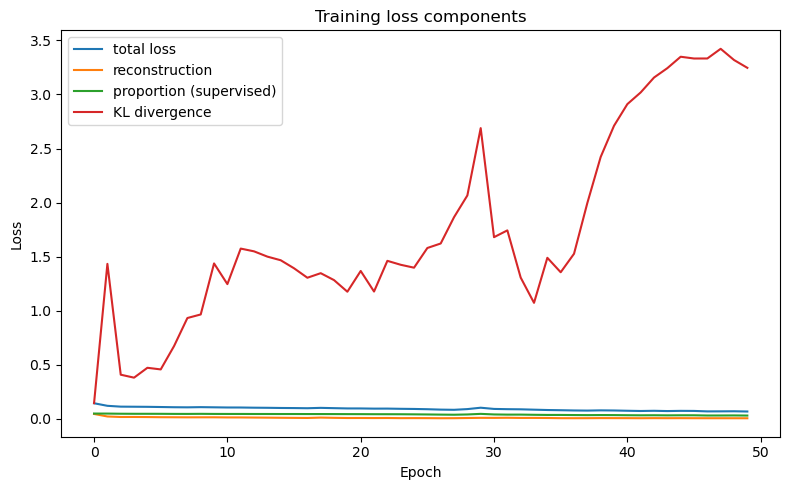

In [6]:
# ---- plot losses ----
plt.figure(figsize=(8,5))
plt.plot(history["loss"], label="total loss")
plt.plot(history["recon"], label="reconstruction")
plt.plot(history["sup"], label="proportion (supervised)")
plt.plot(history["kl"], label="KL divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss components")
plt.legend()
plt.tight_layout()
plt.show()

# Overfitting Sanity Check for VAEProportions

To validate the VAE implementation, I trained it on a deliberately tiny subset of the data. The model quickly drove the training loss and MAE close to zero, confirming that the architecture and loss wiring are functioning correctly. At the same time, the test MAE remained substantially higher, revealing a clear generalization gap—exactly the behavior expected when overfitting a small dataset. The KL divergence term grew large due to kl_weight=0.0, but this was intentional to make overfitting easier and does not affect the validity of the test. Overall, the results confirm that the model can memorize small data and is ready for more realistic training with proper regularization.

[TinyFit] Epoch 001 | train: loss=0.2299 recon=0.0655 prop=0.0548 kl=0.002239 mae=0.1734 | test:  loss=0.1819 recon=0.0439 prop=0.0460 kl=0.086410 mae=0.1679
[TinyFit] Epoch 050 | train: loss=0.1155 recon=0.0076 prop=0.0360 kl=3.899907 mae=0.1474 | test:  loss=0.1273 recon=0.0114 prop=0.0386 kl=3.126971 mae=0.1513
[TinyFit] Epoch 100 | train: loss=0.0415 recon=0.0051 prop=0.0122 kl=17.642517 mae=0.0805 | test:  loss=0.1191 recon=0.0096 prop=0.0365 kl=14.735998 mae=0.1450
[TinyFit] Epoch 150 | train: loss=0.0217 recon=0.0034 prop=0.0061 kl=18.609879 mae=0.0490 | test:  loss=0.1022 recon=0.0078 prop=0.0315 kl=15.918055 mae=0.1253
[TinyFit] Epoch 200 | train: loss=0.0178 recon=0.0024 prop=0.0051 kl=18.754845 mae=0.0467 | test:  loss=0.1032 recon=0.0086 prop=0.0316 kl=15.766966 mae=0.1259
[TinyFit] Epoch 250 | train: loss=0.0136 recon=0.0021 prop=0.0038 kl=19.055618 mae=0.0387 | test:  loss=0.0932 recon=0.0095 prop=0.0279 kl=16.399900 mae=0.1202
[TinyFit] Epoch 300 | train: loss=0.0104 rec

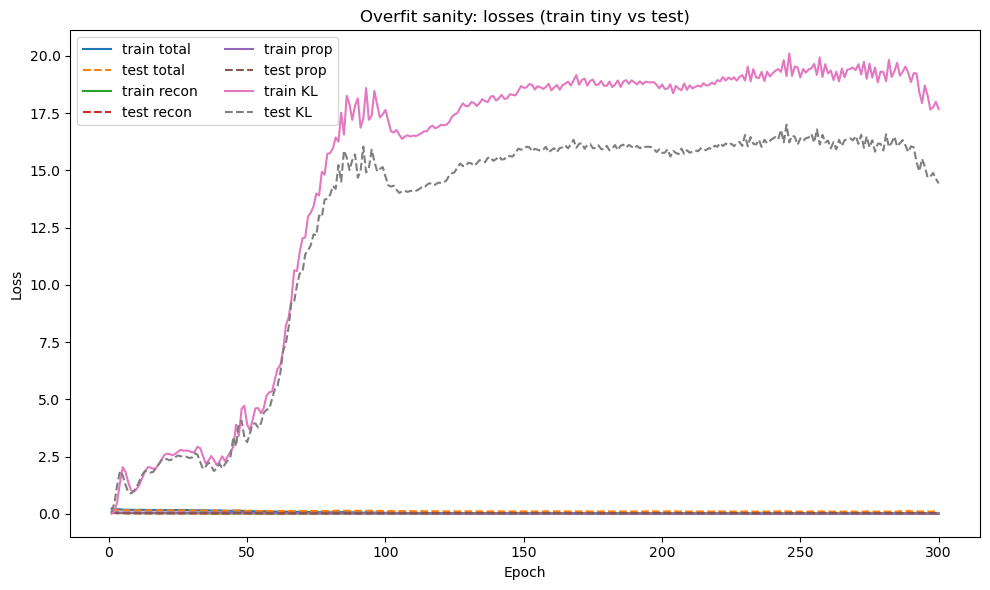

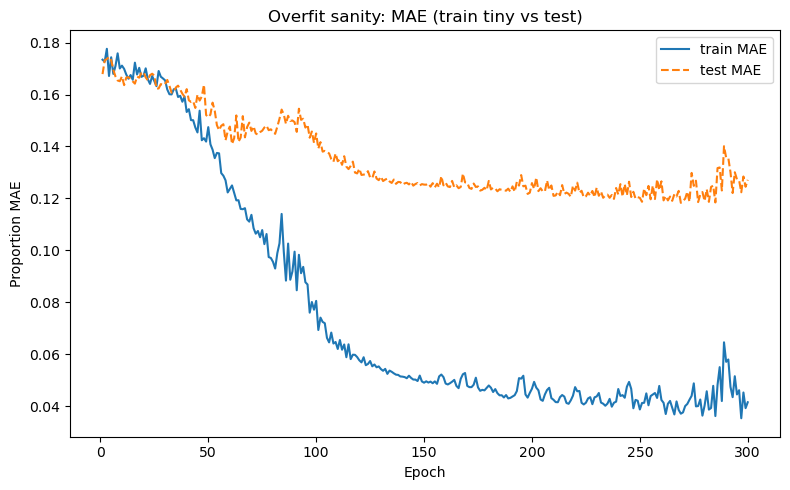

In [7]:
def overfit_sanity(VAEClass, X_train, T_train, X_test, T_test,
                   in_dim, n_classes,
                   latent_dim=32, hidden=(1024,256),
                   kl_weight=0.0,      # turn off KL to make overfitting easier
                   prop_weight=3.0,    # emphasize proportion head
                   lr=1e-3, weight_decay=0.0,
                   n_tiny=16, epochs=300, batch=16, verbose_every=50):

    # pick a tiny subset
    n_tiny = min(n_tiny, len(X_train))
    idx = torch.randperm(len(X_train))[:n_tiny]
    Xtiny = X_train[idx].to(DEVICE)
    Ttiny = T_train[idx].to(DEVICE)

    # fresh model & opt
    model = VAEClass(in_dim=in_dim, latent_dim=latent_dim, hidden=hidden,
                     n_classes=n_classes, kl_weight=kl_weight, prop_weight=prop_weight).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # histories (per-epoch)
    hist_tr = {"loss":[], "recon":[], "sup":[], "kl":[], "mae":[]}
    hist_te = {"loss":[], "recon":[], "sup":[], "kl":[], "mae":[]}

    # --- training over tiny set ---
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(n_tiny, device=DEVICE)
        tot = {"loss":0.0, "recon":0.0, "sup":0.0, "kl":0.0}

        for i in range(0, n_tiny, batch):
            j = perm[i:i+batch]
            xb, tb = Xtiny[j], Ttiny[j]
            opt.zero_grad()
            x_hat, p_hat, mu, logv = model(xb)
            loss, recon, sup, kl = model.loss_fn(xb, x_hat, tb, p_hat, mu, logv)
            loss.backward(); opt.step()
            n = xb.size(0)
            tot["loss"]  += loss.item()*n
            tot["recon"] += recon.item()*n
            tot["sup"]   += sup.item()*n
            tot["kl"]    += kl.item()*n

        # averages on tiny-train
        for k in tot: tot[k] /= n_tiny
        with torch.no_grad():
            _, p_hat_tr, _, _ = model(Xtiny)
            mae_tr = torch.mean(torch.abs(p_hat_tr - Ttiny)).item()
        for k in ["loss","recon","sup","kl"]: hist_tr[k].append(tot[k])
        hist_tr["mae"].append(mae_tr)

        # evaluate on full test each epoch
        model.eval()
        with torch.no_grad():
            totals_te = {"loss":0.0, "recon":0.0, "sup":0.0, "kl":0.0}
            Nte = len(X_test)
            for i in range(0, Nte, 256):
                xb = X_test[i:i+256].to(DEVICE)
                tb = T_test[i:i+256].to(DEVICE)
                x_hat, p_hat, mu, logv = model(xb)
                loss, recon, sup, kl = model.loss_fn(xb, x_hat, tb, p_hat, mu, logv)
                n = xb.size(0)
                totals_te["loss"]  += loss.item()*n
                totals_te["recon"] += recon.item()*n
                totals_te["sup"]   += sup.item()*n
                totals_te["kl"]    += kl.item()*n
            for k in totals_te: totals_te[k] /= Nte
            _, p_hat_te, _, _ = model(X_test.to(DEVICE))
            mae_te = torch.mean(torch.abs(p_hat_te - T_test.to(DEVICE))).item()

        for k in ["loss","recon","sup","kl"]: hist_te[k].append(totals_te[k])
        hist_te["mae"].append(mae_te)

        if ep % verbose_every == 0 or ep == 1:
            print(f"[TinyFit] Epoch {ep:03d} | "
                  f"train: loss={tot['loss']:.4f} recon={tot['recon']:.4f} prop={tot['sup']:.4f} kl={tot['kl']:.6f} mae={mae_tr:.4f} | "
                  f"test:  loss={totals_te['loss']:.4f} recon={totals_te['recon']:.4f} prop={totals_te['sup']:.4f} kl={totals_te['kl']:.6f} mae={mae_te:.4f}")

    # final one-line summary like before
    print(f"\nTiny-set MAE (should be small): {hist_tr['mae'][-1]:.4f}")
    print(f"Test-set MAE (likely larger):   {hist_te['mae'][-1]:.4f}")

    # --- plots: train vs test (loss components + MAE) ---
    x = range(1, epochs+1)

    plt.figure(figsize=(10,6))
    plt.plot(x, hist_tr["loss"],  label="train total")
    plt.plot(x, hist_te["loss"],  "--", label="test total")
    plt.plot(x, hist_tr["recon"], label="train recon")
    plt.plot(x, hist_te["recon"], "--", label="test recon")
    plt.plot(x, hist_tr["sup"],   label="train prop")
    plt.plot(x, hist_te["sup"],   "--", label="test prop")
    plt.plot(x, hist_tr["kl"],    label="train KL")
    plt.plot(x, hist_te["kl"],    "--", label="test KL")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title("Overfit sanity: losses (train tiny vs test)")
    plt.legend(ncol=2); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(x, hist_tr["mae"], label="train MAE")
    plt.plot(x, hist_te["mae"], "--", label="test MAE")
    plt.xlabel("Epoch"); plt.ylabel("Proportion MAE")
    plt.title("Overfit sanity: MAE (train tiny vs test)")
    plt.legend(); plt.tight_layout(); plt.show()

    return model

tiny_model = overfit_sanity(
    VAEClass=VAEProp,
    X_train=Xtr, T_train=Ttr,
    X_test=Xte,  T_test=Tte,
    in_dim=n_cpgs, n_classes=n_celltypes,
    latent_dim=32, hidden=(1024,256),
    kl_weight=0.0, prop_weight=3.0,
    lr=1e-3, 
    weight_decay=0.0,
    n_tiny=16,  # only 16 samples
    epochs=300, # way more epochs than before (50) to make it easier to overfit
    batch=16,  # Small batch that equals the tiny set; so each step sees the whole tiny set (or most of it), which speeds memorization
    verbose_every=50
)

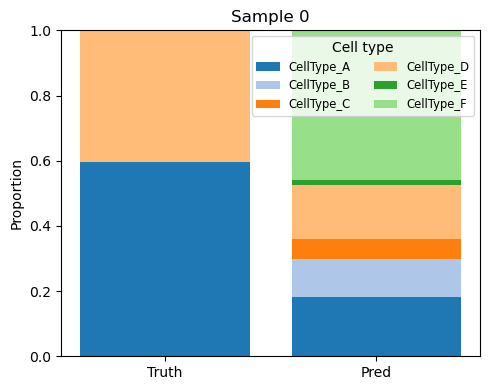

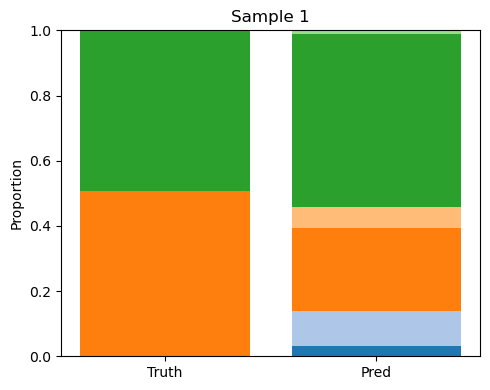

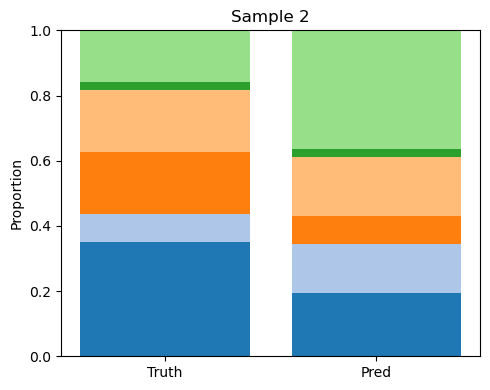

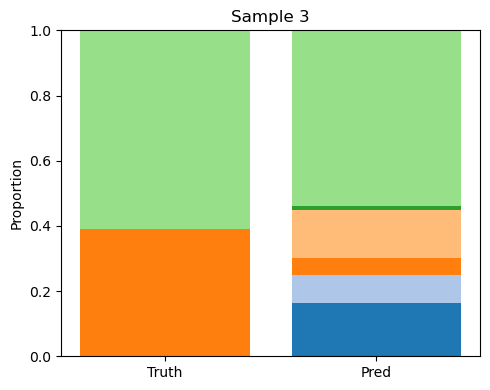

In [8]:
# ---------- Plot: Truth vs Pred stacked side-by-side (first 4 test samples) ----------
celltypes = list(ref_aln.columns)

def plot_truth_vs_pred_stacked(T_mat, P_mat, celltypes, k=4):
    k = min(k, len(T_mat))
    # fixed palette: one color per cell type, reused for both bars
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i % 20) for i in range(len(celltypes))]

    for i in range(k):
        truth = T_mat[i]
        pred  = P_mat[i]

        fig, ax = plt.subplots(figsize=(5, 4))
        x = [0, 1]            # 0=Truth, 1=Pred
        bottoms = [0.0, 0.0]

        for j, ct in enumerate(celltypes):
            color = colors[j]
            # same color for the same cell type on both bars
            ax.bar(x[0], truth[j], bottom=bottoms[0], color=color, edgecolor="none",
                   label=ct if i == 0 else None)
            ax.bar(x[1], pred[j],  bottom=bottoms[1], color=color, edgecolor="none")
            bottoms[0] += truth[j]
            bottoms[1] += pred[j]

        ax.set_xticks(x, ["Truth", "Pred"])
        ax.set_ylim(0, 1)
        ax.set_ylabel("Proportion")
        ax.set_title(f"Sample {i}")
        if i == 0:
            ax.legend(ncol=2, fontsize="small", title="Cell type")
        plt.tight_layout()
        plt.show()

plot_truth_vs_pred_stacked(T_test, p_hat_np, celltypes, k=4)

### Unsupervised non-negative matrix factorization (NMF)


Non-negative matrix factorization (NMF) is great in this context because both both the “basis” (reference-like profiles) and the “coefficients” (proportions) are constrained to be non-negative. This matches biology: methylation levels are ≥0, and cell type proportions are ≥0 and sum to one. With NMF, each column of the “basis” matrix can often be directly interpreted as a cell type profile (or close to it), wheareas when it comes to e.g. PCA components are linear combinations of all features, often mixing cell types in ways that aren’t biologically meaningful.

NMF factorizes Y (CpGs×samples) ≈ W (CpGs×k) · H (k×samples). Treat the rows of H (after column-normalization) as cell-type proportions. Because NMF components are unordered, I align them to ground truth with the Hungarian algorithm.

Inspired by https://www.nature.com/articles/s43018-022-00356-3
LAter I might try semi-supervised NMF similoar to https://academic.oup.com/nar/article/49/9/e50/6129341 (even though its in the spatial omics context).

NMF overall MAE: 0.1484
Sample_1    0.212331
Sample_2    0.085243
Sample_3    0.214676
Sample_4    0.112776
Sample_5    0.212758
dtype: float64


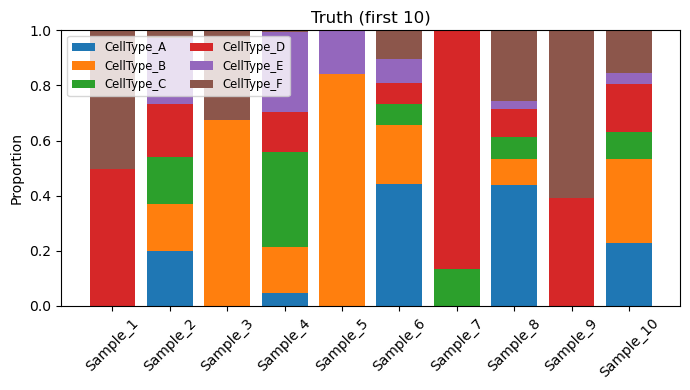

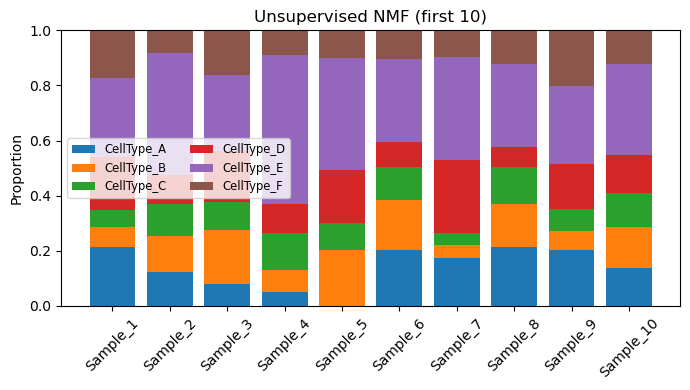

In [9]:
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment

# NMF tutorial: https://medium.com/@quindaly/step-by-step-nmf-example-in-python-9974e38dc9f9
# Inputs you already have:
# ref_aln: CpGs×celltypes DataFrame
# mix_aln: CpGs×samples   DataFrame
# truth  : celltypes×samples DataFrame

R = ref_aln.values.astype(float)             # (p × k)  # is there for reference; vanilla NMF doesn’t use it (handy if I later want to try semi-supervised NMF).
Y = mix_aln.values.astype(float)             # (p × n) # data we factorize: CpGs (p) by samples (n)

celltypes = list(ref_aln.columns)            # length k
samples   = list(mix_aln.columns)            # length n
k = len(celltypes) # the number of components we want (cell types).
n = len(samples)

# --- NMF factorization: Y ≈ W (p×k) @ H (k×n) ---
# Decomposes Y ≈ Wm @ Hm with non-negativity on both matrices.
# Wm ≈ CpG “loadings” per component (cell-type-like signatures).
# Hm ≈ per-sample activations of each component.
# nndsvda is a good initializer for non-negative data; max_iter generous so it converges.
# Here I dont bother with finding the best rank; it’s a controlled experiment where the ground truth is available.
nmf = NMF(n_components=k, init="nndsvda", max_iter=2000, random_state=0)
Wm = nmf.fit_transform(Y)        # (p × k)
Hm = nmf.components_             # (k × n)

# Each column of Hm (a sample) is normalized to sum to 1 → proportions per sample.
P_hat = Hm / (Hm.sum(axis=0, keepdims=True) + 1e-12)   # (k × n)

# Ground truth in the SAME order (rows=celltypes, cols=samples)
T_true = truth.loc[celltypes, samples].values          # (k × n)

# --- Build k×k correlation matrix between rows of P_hat and rows of T_true ---
# Center rows
A = P_hat - P_hat.mean(axis=1, keepdims=True)          # (k × n)
B = T_true - T_true.mean(axis=1, keepdims=True)        # (k × n)

# Row norms
An = np.sqrt((A**2).sum(axis=1, keepdims=True)) + 1e-12
Bn = np.sqrt((B**2).sum(axis=1, keepdims=True)) + 1e-12

# Correlation matrix C[i,j] = corr(P_hat[i], T_true[j])
C = (A @ B.T) / (An @ Bn.T)                            # (k × k)

# Hungarian assignment to maximize total correlation (minimize negative corr)
# Hungarian alignment fixes the label-swapping issue (NMF's components are unlabeled).
row_ind, col_ind = linear_sum_assignment(-C) # maximize correlation == minimize negative correlation

# Reorder P_hat rows to match truth row order
# row_ind[i] in P_hat corresponds to col_ind[i] in truth; build inverse permutation
perm = np.argsort(col_ind) # reorder to truth’s row order
P_hat_final = P_hat[row_ind][perm]                     # (k × n)

# To DataFrame aligned with truth
P_hat_df = pd.DataFrame(P_hat_final, index=celltypes, columns=samples)

# --- Evaluate (MAE) ---
mae_overall = (P_hat_df - truth).abs().values.mean()
mae_per_sample = (P_hat_df - truth).abs().mean(axis=0)

print(f"NMF overall MAE: {mae_overall:.4f}")
print(mae_per_sample.head())

# Optional quick plots on a subset
def plot_stacked(W, title):
    import matplotlib.pyplot as plt
    xs = np.arange(W.shape[1])
    bottom = np.zeros(W.shape[1])
    plt.figure(figsize=(7,4))
    for ct in W.index:
        vals = W.loc[ct].values
        plt.bar(xs, vals, bottom=bottom, label=ct)
        bottom += vals
    plt.xticks(xs, W.columns, rotation=45)
    plt.ylim(0,1); plt.ylabel("Proportion"); plt.title(title); plt.legend(ncol=2, fontsize="small")
    plt.tight_layout(); plt.show()

subset = samples[:10]
plot_stacked(truth[subset],   "Truth (first 10)")
plot_stacked(P_hat_df[subset],"Unsupervised NMF (first 10)")


# Semi-supervised NMF

A practical way to make NMF "semi-supervised" with the reference is to anchor the basis matrix **W** toward the reference **R**. Concretely, we minimize

$$
\min_{W \geq 0, H \geq 0} \; \|Y - WH\|_F^2 + \lambda \|W - R\|_F^2
$$

where **Y** is observed mixtures  CpGs × samples, **R** is reference methylation profiles CpGs × cell types, **W** is learned basis (non-negative) CpGs × cell types, and **H** activations/proportions (non-negative) is cell types × samples. The λ term keeps **W** close to **R** but still lets it adapt to data (e.g., platform/batch differences); anchoring strength.


### Algorithm (alternating updates):

- **H-update:** solve non-negative least squares per sample (using scipy.optimize.nnls) and optionally normalize columns to sum to 1 → proportions.

- **W-update (anchored ridge step):** closed-form ridge solution, then project to non-negative:

$$
W \leftarrow (YH^\top + \lambda R)(HH^\top + \lambda I)^{-1}, 
\quad 
W \leftarrow \max(W, 0).
$$

Because **W** stays close to **R**, the component order matches your reference cell types, so you usually don’t need Hungarian alignment.

This approach is inspired by [ssNMF](https://github.com/nloyfer/ssNMF), that also aims to factorize $Y ≈ WH$ while pulling $W$ toward a known reference $R$ (so components align with cell types).


In [10]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls

def semi_supervised_nmf_anchor(ref_aln, mix_aln, truth,
                               lam=1.0,
                               max_iter=200,
                               tol=1e-5,
                               sum_to_one=True,
                               verbose=True,
                               seed=0):
    """
    Semi-supervised NMF with anchoring of W toward R:
        minimize ||Y - W H||_F^2 + lam * ||W - R||_F^2
    with W >= 0, H >= 0.
    
    Inputs
    ------
    ref_aln : DataFrame (CpGs × celltypes)
    mix_aln : DataFrame (CpGs × samples)
    truth   : DataFrame (celltypes × samples)  [only used for evaluation]
    
    Returns
    -------
    W_df : DataFrame (CpGs × celltypes)  learned basis, anchored to ref
    H_df : DataFrame (celltypes × samples) nonnegative activations
    P_df : DataFrame (celltypes × samples) proportions (columns sum to 1 if sum_to_one=True)
    hist : dict of losses across iterations
    """

    rng = np.random.default_rng(seed)

    # matrices
    celltypes = list(ref_aln.columns)
    samples   = list(mix_aln.columns)

    R = ref_aln.loc[:, celltypes].values.astype(float)  # (p × k)
    Y = mix_aln.loc[:, samples].values.astype(float)    # (p × n)
    k = R.shape[1]
    p, n = Y.shape

    # --- initialization ---
    # Start W near R; small nonneg noise
    W = np.clip(R + rng.normal(0, 0.01, size=R.shape), 0, None)

    # Initialize H by NNLS per sample using initial W
    # Start W near the reference R (semi-supervised “warm start”), then clip negatives to 0
    H = np.zeros((k, n), dtype=float)
    for j in range(n):
        h_j, _ = nnls(W, Y[:, j])
        H[:, j] = h_j
    if sum_to_one:
        colsum = H.sum(axis=0, keepdims=True) + 1e-12
        H = H / colsum

    hist = {"obj": []}

    # Pre-allocate for speed
    I_k = np.eye(k)

    # --- alternating minimization ---
    for it in range(1, max_iter + 1):

        # Update W (anchored ridge step) and project to nonneg
        # W = (Y H^T + lam R) (H H^T + lam I)^(-1)
        # W-update (anchored ridge step)
        HHt = H @ H.T
        try:
            W_new = (Y @ H.T + lam * R) @ np.linalg.inv(HHt + lam * I_k)
        except np.linalg.LinAlgError:
            # add tiny jitter if ill-conditioned
            W_new = (Y @ H.T + lam * R) @ np.linalg.pinv(HHt + lam * I_k + 1e-8 * I_k)

        W_new = np.clip(W_new, 0, None)

        # Update H by NNLS per sample (using updated W)
        H_new = np.zeros_like(H)
        for j in range(n):
            h_j, _ = nnls(W_new, Y[:, j])
            H_new[:, j] = h_j

        if sum_to_one:
            colsum = H_new.sum(axis=0, keepdims=True) + 1e-12
            H_new = H_new / colsum

        # Compute objective
        # Compute objective & check convergence
        recon = np.linalg.norm(Y - W_new @ H_new, ord='fro')**2
        anchor = np.linalg.norm(W_new - R, ord='fro')**2
        obj = recon + lam * anchor
        hist["obj"].append(obj)

        # Check convergence (relative change) and record the total loss and its parts
        if it > 1:
            rel = abs(hist["obj"][-2] - obj) / (hist["obj"][-2] + 1e-12)
            if verbose and (it % 10 == 0 or it == 1):
                print(f"[iter {it:03d}] obj={obj:.6e}  recon={recon:.6e}  anchor={anchor:.6e}  Δrel={rel:.3e}")
            if rel < tol:
                if verbose:
                    print(f"Converged at iter {it} (Δrel={rel:.3e})")
                W, H = W_new, H_new
                break
        else:
            if verbose:
                print(f"[iter {it:03d}] obj={obj:.6e}  recon={recon:.6e}  anchor={anchor:.6e}")

        W, H = W_new, H_new

    # Wrap outputs
    W_df = pd.DataFrame(W, index=ref_aln.index, columns=celltypes)
    H_df = pd.DataFrame(H, index=celltypes, columns=samples)

    # proportions (same as H if we normalized columns)
    P_df = H_df.copy()

    # Quick evaluation if truth provided on same axes
    if truth is not None:
        truth_aln = truth.loc[celltypes, samples]
        mae_overall = (P_df - truth_aln).abs().values.mean()
        mae_per_sample = (P_df - truth_aln).abs().mean(axis=0)
        print(f"\nSemiNMF (anchored) overall MAE: {mae_overall:.4f}")
        print(mae_per_sample.head())

    return W_df, H_df, P_df, hist


[iter 001] obj=1.951167e+03  recon=1.899881e+03  anchor=1.025729e+01
[iter 010] obj=1.932446e+03  recon=1.895053e+03  anchor=7.478594e+00  Δrel=1.053e-04
[iter 020] obj=1.933218e+03  recon=1.895425e+03  anchor=7.558580e+00  Δrel=1.008e-05
Converged at iter 29 (Δrel=8.649e-07)

SemiNMF (anchored) overall MAE: 0.0183
Sample_1    0.014963
Sample_2    0.012547
Sample_3    0.009401
Sample_4    0.015266
Sample_5    0.031944
dtype: float64


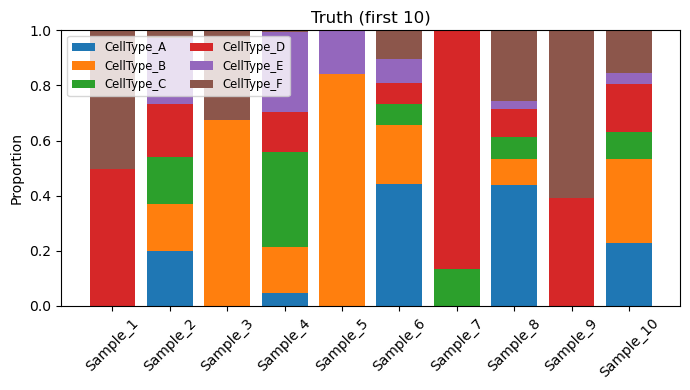

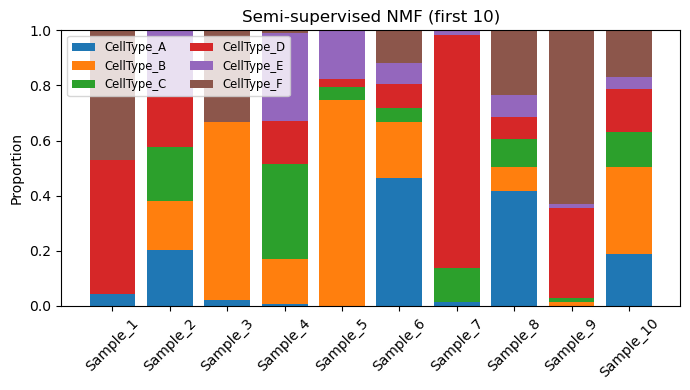

In [11]:
W_semi, H_semi, P_semi, hist = semi_supervised_nmf_anchor(
    ref_aln=ref_aln,
    mix_aln=mix_aln,
    truth=truth,          # used only for MAE printout
    lam=5.0,              # try 0.1, 1, 5, 10 to see the trade-off; how strongly to pull W toward R. Larger = stickier to reference
    max_iter=300,
    tol=1e-6,
    sum_to_one=True,
    verbose=True,
    seed=0
)

# Compare a few samples
subset = mix_aln.columns[:10]
plot_stacked(truth[subset],  "Truth (first 10)")
plot_stacked(P_semi[subset], "Semi-supervised NMF (first 10)")


# Tiny Deconv-Transformer

This tiny transformer is a sequence model applied to CpG regions. Each sample is treated as a sequence of “tokens”:
- Each token = a CpG region with:
    - Region ID (learned embedding → tells the model which CpG it is).
    - Region feature(s) (e.g. methylation beta value at that CpG).
- Tokens go into a Transformer encoder:
    - Self-attention lets each CpG region “talk” to all others, so the model can learn global methylation patterns, not just per-region signals.
- The encoder’s output is pooled (averaged) → a representation of the whole sample.
- A small MLP head + softmax maps that pooled embedding into predicted cell-type proportions $H_hat$.

Meanwhile, there’s also a learnable basis matrix W (regions × cell types).
- It starts near your reference R.
- During training, it adjusts — but is penalized if it drifts too far (anchor loss).
- This allows the model to adapt references to the data (e.g. account for batch/platform effects).

------


Why this is different from previous methods?

- Regression: Solves $Y≈HR⊤$ directly, assuming R is fixed and perfect.
- NMF: Factorizes $Y≈WH$ with no sequence model, usually sensitive to initialization.
- VAE: Learns a latent space, but not specifically tuned for sequential CpG context.
- Transformer: Uses attention → can capture which regions co-vary and adjust weights dynamically. It’s more expressive, especially if certain CpGs are more informative than others.


In [17]:
# ============================================================
# Tiny Deconv-Transformer for cfDNA-like mixtures (one file)
# Lightweight defaults for a laptop (CPU-friendly)
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -------------------------
# Repro / device / threads
# -------------------------
SEED = 7
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(min(4, os.cpu_count() or 4))   # keep laptop responsive
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True

# -------------------------
# Hyperparameters (light)
# -------------------------
P       = 500    # regions (tokens)
K       = 5      # cell types
N       = 400    # samples
NOISE   = 0.02   # Gaussian noise sigma on beta
P_SUB   = 256    # subsample regions per step for speed
BATCH   = 32
EPOCHS  = 30
D_MODEL = 64
LAYERS  = 2
HEADS   = 4
DROPOUT = 0.1
LR_ENC  = 2e-4
LR_HEAD = 1e-3
LAMBDA  = 1.0    # anchor strength to reference R


# -------------------------
# Dataset
# -------------------------
class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, reg_ids, reg_feats, Y, Htrue):
        self.reg_ids = torch.tensor(reg_ids, dtype=torch.long)
        self.reg_feats = torch.tensor(reg_feats, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.Htrue = torch.tensor(Htrue, dtype=torch.float32)
    def __len__(self):
        return self.Y.shape[0]
    def __getitem__(self, i):
        return self.reg_ids[i], self.reg_feats[i], self.Y[i], self.Htrue[i]

# -------------------------
# Tiny Deconv-Transformer
#   - region id embedding + feature projection
#   - TransformerEncoder over tokens (regions)
#   - mean pool -> MLP head -> softmax proportions
#   - learns W (regions x celltypes), anchored to R
# -------------------------
class TinyDeconvTransformer(nn.Module):
    def __init__(self, n_regions, feat_dim, d_model, n_layers, n_heads, n_cells, R_ref, dropout=0.1):
        super().__init__()
        self.n_regions = n_regions
        self.n_cells = n_cells

        self.reg_emb = nn.Embedding(n_regions, d_model)
        self.feat_proj = nn.Linear(feat_dim, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=4*d_model,
            dropout=dropout, batch_first=True, activation="gelu", norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.prop_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_cells)
        )

        # learnable W initialized near R_ref
        R_t = torch.tensor(R_ref, dtype=torch.float32)
        self.W = nn.Parameter(R_t.clone())  # [P,K]

        # init
        nn.init.trunc_normal_(self.reg_emb.weight, std=0.02)
        nn.init.trunc_normal_(self.feat_proj.weight, std=0.02)
        nn.init.zeros_(self.feat_proj.bias)
        for m in self.prop_head:
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, reg_ids, reg_feats):
        # reg_ids: [B, P?] indices 0..n_regions-1
        # reg_feats: [B, P?, feat_dim] e.g., beta signal (and possibly other features)
        e = self.reg_emb(reg_ids)                   # [B,P?,D]
        f = self.feat_proj(reg_feats)               # [B,P?,D]
        x = e + f                                   # token rep
        x = self.encoder(x)                         # [B,P?,D]
        x = x.mean(dim=1)                           # [B,D] (mean pool)
        logits = self.prop_head(x)                  # [B,K]
        H_hat = torch.softmax(logits, dim=-1)       # simplex proportions
        return H_hat

# -------------------------
# Metrics
# -------------------------
def pearson_colwise_mean(Hhat_np, Htrue_np):
    # Pearson r per cell type across samples, then mean
    K = Htrue_np.shape[1]
    rs = []
    for k in range(K):
        a = Htrue_np[:, k]; b = Hhat_np[:, k]
        if np.allclose(a.std(), 0) or np.allclose(b.std(), 0):
            rs.append(0.0)
        else:
            r = np.corrcoef(a, b)[0, 1]
            rs.append(float(r))
    return float(np.nanmean(rs))

def mae_colwise_mean(Hhat_np, Htrue_np):
    return float(np.mean(np.abs(Hhat_np - Htrue_np)))





1A. Toy data simulator - cell types are generated with smoother, more distinct sinusoidal patterns.

/home/katwre/miniforge3/envs/genomics_torch/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 01 | train 0.0097 | val 0.0112 | mean r=0.221 | mean MAE=0.138
Epoch 02 | train 0.0097 | val 0.0110 | mean r=0.259 | mean MAE=0.138
Epoch 03 | train 0.0099 | val 0.0109 | mean r=0.221 | mean MAE=0.138
Epoch 04 | train 0.0098 | val 0.0111 | mean r=0.422 | mean MAE=0.138
Epoch 05 | train 0.0098 | val 0.0111 | mean r=0.284 | mean MAE=0.138
Epoch 06 | train 0.0098 | val 0.0109 | mean r=0.367 | mean MAE=0.138
Epoch 07 | train 0.0096 | val 0.0104 | mean r=0.394 | mean MAE=0.134
Epoch 08 | train 0.0087 | val 0.0091 | mean r=0.455 | mean MAE=0.125
Epoch 09 | train 0.0083 | val 0.0077 | mean r=0.519 | mean MAE=0.115
Epoch 10 | train 0.0073 | val 0.0059 | mean r=0.639 | mean MAE=0.093
Epoch 11 | train 0.0064 | val 0.0047 | mean r=0.681 | mean MAE=0.081
Epoch 12 | train 0.0066 | val 0.0052 | mean r=0.681 | mean MAE=0.086
Epoch 13 | train 0.0061 | val 0.0050 | mean r=0.706 | mean MAE=0.087
Epoch 14 | train 0.0056 | val 0.0054 | mean r=0.677 | mean MAE=0.089
Epoch 15 | train 0.0056 | val 0.00

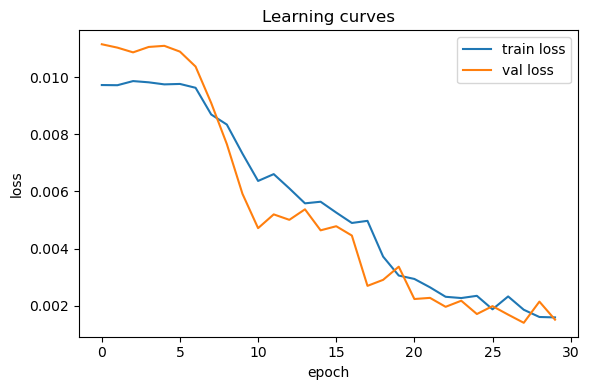

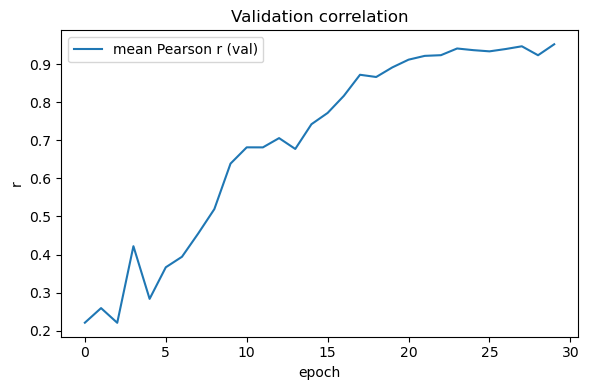

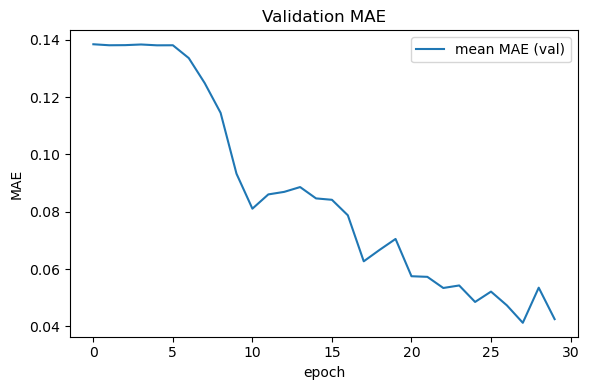

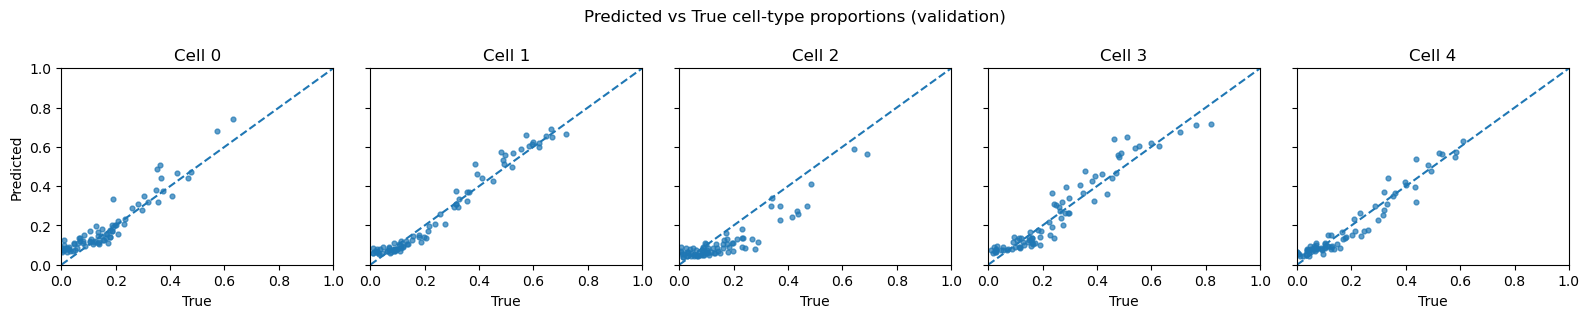

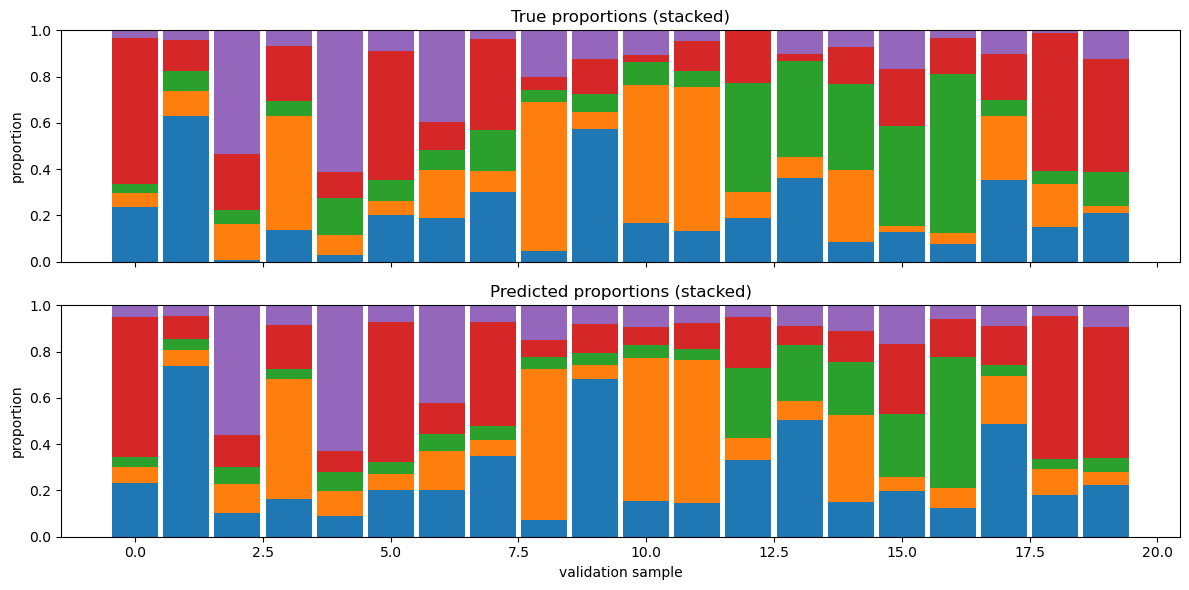

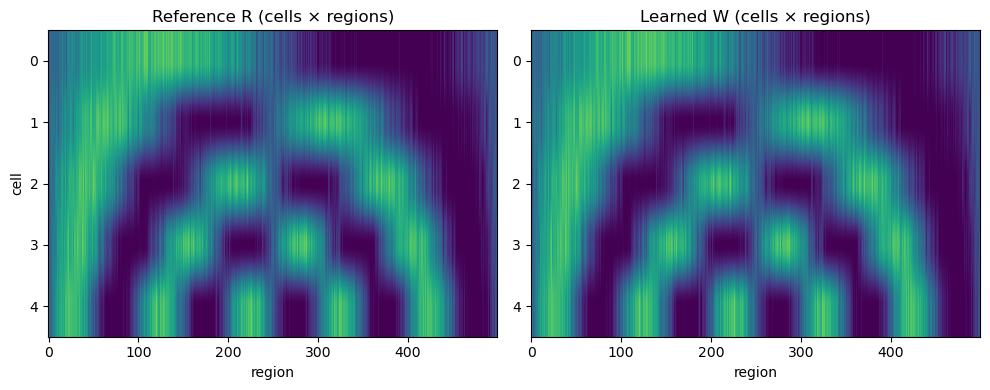

In [18]:

# ============================================================
# ------------------------- RUN ------------------------------
# ============================================================

# -------------------------
# Toy data simulator
# Cell types are generated with smoother, more distinct sinusoidal patterns.
# Less correlation between columns of R.
# The anchor Rref matches the true R (no mismatch).
# This is a much easier toy problem, so the Transformer quickly learns neat diagonal scatterplots and high correlations
# -------------------------

def simulate_data(P=1000, K=5, N=500, noise_sigma=0.02):
    # reference profiles R in [0,1], regions x celltypes
    # structure: each cell type has slightly different baseline + smooth bumps
    x = np.linspace(0, 1, P, dtype=np.float32)
    R = []
    rng = np.random.default_rng(123)
    for k in range(K):
        base = 0.3 + 0.4 * np.sin(2*np.pi*(k+1)*x)  # smooth pattern per cell
        base = base + 0.05 * rng.normal(size=P)     # small jitter
        base = np.clip(base, 0, 1)
        R.append(base)
    R = np.stack(R, axis=1).astype(np.float32)      # [P,K]

    # sample proportions H on simplex via Dirichlet
    H = rng.dirichlet(alpha=np.ones(K, dtype=np.float32), size=N).astype(np.float32)  # [N,K]
    # mix: Y = H @ R^T  -> [N,P]
    Y = (H @ R.T).astype(np.float32)
    if noise_sigma > 0:
        Y += noise_sigma * rng.normal(size=Y.shape).astype(np.float32)
    Y = np.clip(Y, 0, 1)
    return R, Y, H

# ---- data ----
R_np, Y_np, Htrue_np = simulate_data(P=P, K=K, N=N, noise_sigma=NOISE)
idx = np.arange(N); np.random.shuffle(idx); split = int(0.8*N)
tr_idx, va_idx = idx[:split], idx[split:]
Y_tr, Y_va = Y_np[tr_idx], Y_np[va_idx]
H_tr, H_va = Htrue_np[tr_idx], Htrue_np[va_idx]

# Tokens: region ids are 0..P-1; features = β (1 feature here; you can add coverage etc.)
reg_ids_all   = np.tile(np.arange(P, dtype=np.int64)[None, :], (N, 1))  # [N,P]
reg_feats_all = Y_np[..., None]                                         # [N,P,1]
reg_ids_tr, reg_ids_va     = reg_ids_all[tr_idx], reg_ids_all[va_idx]
reg_feats_tr, reg_feats_va = reg_feats_all[tr_idx], reg_feats_all[va_idx]

train_ds = SimpleDataset(reg_ids_tr, reg_feats_tr, Y_tr, H_tr)
val_ds   = SimpleDataset(reg_ids_va, reg_feats_va, Y_va, H_va)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=False)
val_loader   = torch.utils.data.DataLoader(val_ds, batch_size=BATCH, shuffle=False, drop_last=False)

# ---- model & opt ----
model = TinyDeconvTransformer(
    n_regions=P, feat_dim=1, d_model=D_MODEL, n_layers=LAYERS, n_heads=HEADS,
    n_cells=K, R_ref=R_np, dropout=DROPOUT
).to(DEVICE)

enc_params  = list(model.reg_emb.parameters()) + list(model.feat_proj.parameters()) + list(model.encoder.parameters())
head_params = list(model.prop_head.parameters()) + [model.W]
opt = torch.optim.AdamW(
    [{'params': enc_params,  'lr': LR_ENC},
     {'params': head_params, 'lr': LR_HEAD}],
    weight_decay=1e-4
)

R_t = torch.tensor(R_np, dtype=torch.float32, device=DEVICE)

# histories for plotting
train_hist, val_hist, r_hist, mae_hist = [], [], [], []

# ---- train ----
for epoch in range(1, EPOCHS+1):
    # -------- train --------
    model.train(); tr_loss = 0.0
    for reg_ids_b, reg_feats_b, Y_b, _ in train_loader:
        reg_ids_b   = reg_ids_b.to(DEVICE)        # [B,P]
        reg_feats_b = reg_feats_b.to(DEVICE)      # [B,P,1]
        Y_b         = Y_b.to(DEVICE)              # [B,P]

        # subsample same region subset for the whole batch
        sub_idx = torch.randperm(P, device=DEVICE)[:P_SUB]
        reg_ids_sub   = reg_ids_b[:, sub_idx]          # [B,P_SUB]
        reg_feats_sub = reg_feats_b[:, sub_idx, :]     # [B,P_SUB,1]
        Y_sub         = Y_b[:, sub_idx]                # [B,P_SUB]
        W_sub         = model.W[sub_idx, :]            # [P_SUB,K]
        R_sub         = R_t[sub_idx, :]                # [P_SUB,K]

        H_hat = model(reg_ids_sub, reg_feats_sub)      # [B,K]
        Y_hat = (W_sub @ H_hat.T).T                    # [B,P_SUB]

        mix    = F.mse_loss(Y_hat, Y_sub)
        anchor = F.mse_loss(W_sub, R_sub)
        loss   = mix + LAMBDA * anchor

        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        tr_loss += loss.item() * Y_b.size(0)
    tr_loss /= len(train_ds)

    # -------- validate --------
    model.eval(); va_loss = 0.0; all_Hhat = []; all_Htrue = []
    with torch.no_grad():
        for reg_ids_b, reg_feats_b, Y_b, Htrue_b in val_loader:
            reg_ids_b   = reg_ids_b.to(DEVICE)
            reg_feats_b = reg_feats_b.to(DEVICE)
            Y_b         = Y_b.to(DEVICE)
            Htrue_b     = Htrue_b.to(DEVICE)

            sub_idx = torch.randperm(P, device=DEVICE)[:P_SUB]
            reg_ids_sub   = reg_ids_b[:, sub_idx]
            reg_feats_sub = reg_feats_b[:, sub_idx, :]
            Y_sub         = Y_b[:, sub_idx]
            W_sub         = model.W[sub_idx, :]
            R_sub         = R_t[sub_idx, :]

            H_hat = model(reg_ids_sub, reg_feats_sub)
            Y_hat = (W_sub @ H_hat.T).T
            mix    = F.mse_loss(Y_hat, Y_sub)
            anchor = F.mse_loss(W_sub, R_sub)
            loss   = mix + LAMBDA * anchor

            va_loss += loss.item() * Y_b.size(0)
            all_Hhat.append(H_hat.detach().cpu().numpy())
            all_Htrue.append(Htrue_b.detach().cpu().numpy())

    va_loss  /= len(val_ds)
    all_Hhat  = np.concatenate(all_Hhat, axis=0)
    all_Htrue = np.concatenate(all_Htrue, axis=0)
    mean_r    = pearson_colwise_mean(all_Hhat, all_Htrue)
    mean_mae  = mae_colwise_mean(all_Hhat, all_Htrue)

    train_hist.append(tr_loss)
    val_hist.append(va_loss)
    r_hist.append(float(mean_r))
    mae_hist.append(float(mean_mae))

    print(f"Epoch {epoch:02d} | train {tr_loss:.4f} | val {va_loss:.4f} | mean r={mean_r:.3f} | mean MAE={mean_mae:.3f}")

# ============================================================
# ------------------------- PLOTS ----------------------------
# ============================================================

# 1) Learning curves
plt.figure(figsize=(6,4))
plt.plot(train_hist, label="train loss")
plt.plot(val_hist, label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Learning curves"); plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(r_hist, label="mean Pearson r (val)")
plt.xlabel("epoch"); plt.ylabel("r"); plt.title("Validation correlation"); plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(mae_hist, label="mean MAE (val)")
plt.xlabel("epoch"); plt.ylabel("MAE"); plt.title("Validation MAE"); plt.legend(); plt.tight_layout()
plt.show()

# 2) Predicted vs True proportions (scatter)
K_use = all_Hhat.shape[1]
fig, axes = plt.subplots(1, K_use, figsize=(3.2*K_use, 3.2), sharex=True, sharey=True)
if K_use == 1:
    axes = [axes]

minv, maxv = 0.0, 1.0
for k in range(K_use):
    ax = axes[k]
    ax.scatter(all_Htrue[:, k], all_Hhat[:, k], s=12, alpha=0.7)
    ax.plot([minv, maxv], [minv, maxv], linestyle="--")
    ax.set_title(f"Cell {k}")
    ax.set_xlabel("True")
    if k == 0: ax.set_ylabel("Predicted")
    ax.set_xlim(minv, maxv); ax.set_ylim(minv, maxv)

plt.suptitle("Predicted vs True cell-type proportions (validation)")
plt.tight_layout()
plt.show()

# 3) Stacked bars (first 20 val samples)
S = min(20, all_Htrue.shape[0])
idx = np.arange(S)
true = all_Htrue[:S]
pred = all_Hhat[:S]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].set_title("True proportions (stacked)")
axes[1].set_title("Predicted proportions (stacked)")

bottom = np.zeros(S)
for k in range(K):
    axes[0].bar(idx, true[:, k], bottom=bottom, width=0.9)
    bottom += true[:, k]

bottom = np.zeros(S)
for k in range(K):
    axes[1].bar(idx, pred[:, k], bottom=bottom, width=0.9)
    bottom += pred[:, k]

axes[1].set_xlabel("validation sample")
for ax in axes:
    ax.set_ylabel("proportion")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 4) Compare learned W to reference R
W_hat = model.W.detach().cpu().numpy()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(R_np.T, aspect="auto", vmin=0, vmax=1)
plt.title("Reference R (cells × regions)"); plt.xlabel("region"); plt.ylabel("cell")

plt.subplot(1,2,2)
plt.imshow(W_hat.T, aspect="auto", vmin=0, vmax=1)
plt.title("Learned W (cells × regions)"); plt.xlabel("region")

plt.tight_layout()
plt.show()

# ========================= End ==============================


1B. Toy data simulator - builds cell-type profiles R as linear combinations of two latent "base" vectors with added noise; the same as for previous methods.

/home/katwre/miniforge3/envs/genomics_torch/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 01 | train 0.0162 | val 0.0175 | mean r=0.300 | mean MAE=0.170
Epoch 02 | train 0.0162 | val 0.0169 | mean r=0.280 | mean MAE=0.170
Epoch 03 | train 0.0159 | val 0.0167 | mean r=0.272 | mean MAE=0.169
Epoch 04 | train 0.0147 | val 0.0139 | mean r=0.394 | mean MAE=0.165
Epoch 05 | train 0.0117 | val 0.0119 | mean r=0.380 | mean MAE=0.161
Epoch 06 | train 0.0092 | val 0.0079 | mean r=0.383 | mean MAE=0.152
Epoch 07 | train 0.0101 | val 0.0088 | mean r=0.383 | mean MAE=0.153
Epoch 08 | train 0.0102 | val 0.0205 | mean r=0.370 | mean MAE=0.169
Epoch 09 | train 0.0082 | val 0.0073 | mean r=0.398 | mean MAE=0.153
Epoch 10 | train 0.0079 | val 0.0080 | mean r=0.415 | mean MAE=0.152
Epoch 11 | train 0.0079 | val 0.0070 | mean r=0.410 | mean MAE=0.150
Epoch 12 | train 0.0080 | val 0.0110 | mean r=0.399 | mean MAE=0.156
Epoch 13 | train 0.0070 | val 0.0063 | mean r=0.422 | mean MAE=0.148
Epoch 14 | train 0.0065 | val 0.0072 | mean r=0.415 | mean MAE=0.150
Epoch 15 | train 0.0075 | val 0.00

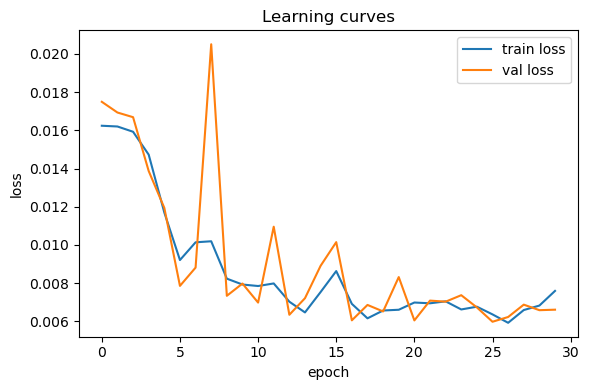

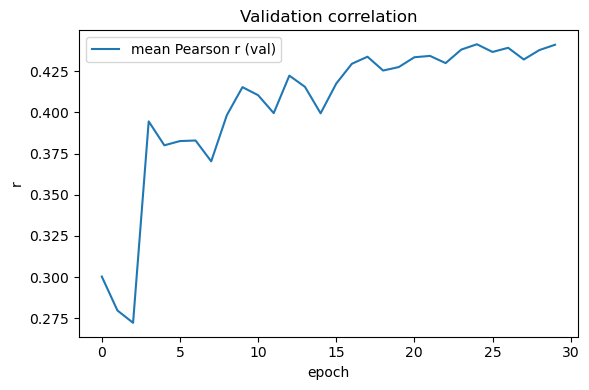

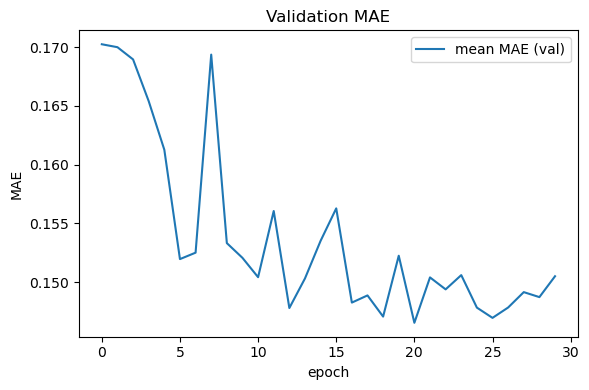

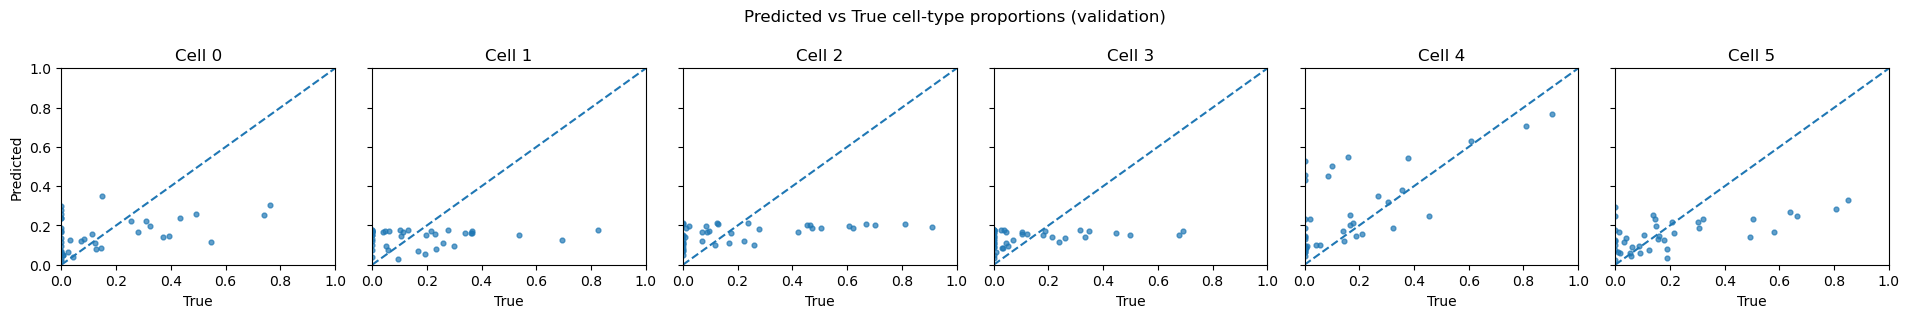

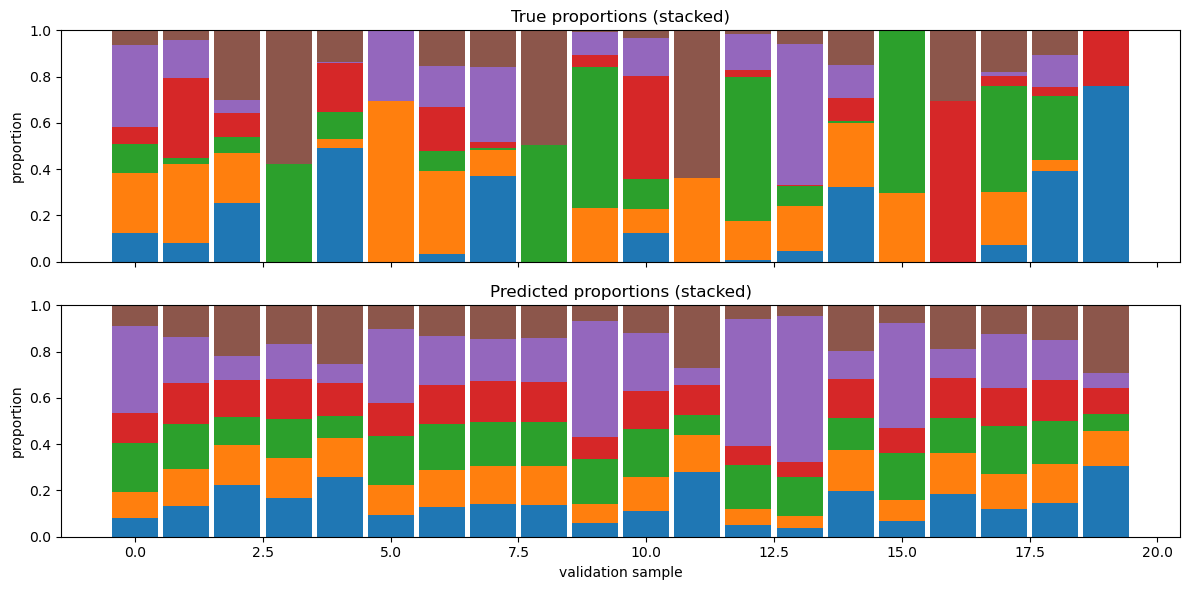

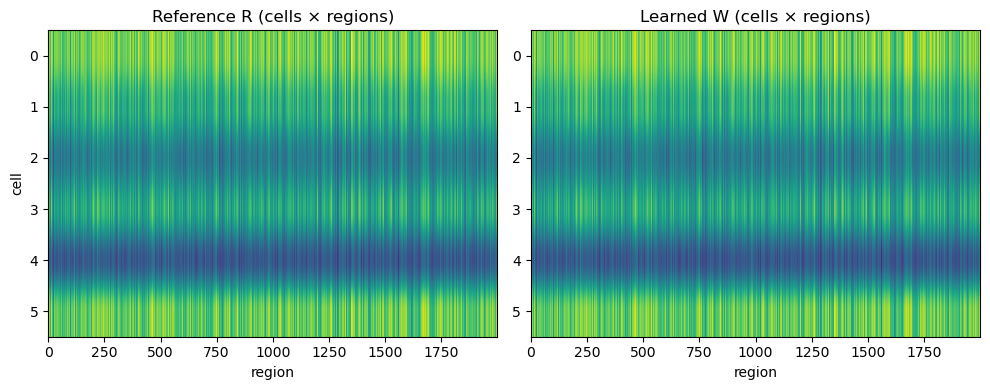

In [19]:

# ============================================================
# ------------------------- RUN ------------------------------
# ============================================================

# ---- 1) Generate the toy dataset as previously ----
ref_df, mix_df, truth = simulate_hard(
    n_cpgs=2000,        # P (regions/CpGs)
    n_celltypes=6,      # K
    n_samples=200,      # N
    noise_sd=0.07,
    seed=123
)
ref_aln, mix_aln = align_by_cpg(ref_df, mix_df)

# Ensure truth index/columns order match ref/mix for perfect alignment
truth = truth.reindex(index=ref_aln.columns, columns=mix_aln.columns)

# ---- 2) Adapt DataFrames to numpy arrays for the model ----
# Shapes we need:
#   R_np: [P, K]   (regions x celltypes)
#   Y_np: [N, P]   (samples x regions)
#   Htrue_np: [N, K] (samples x celltypes)
R_np = ref_aln.values.astype(np.float32)               # [P, K]
Y_np = mix_aln.values.astype(np.float32).T             # mix_aln is [P, N] -> transpose to [N, P]
Htrue_np = truth.values.T.astype(np.float32)           # truth is [K, N] -> transpose to [N, K]

P = R_np.shape[0]
K = R_np.shape[1]
N = Y_np.shape[0]

# ---- 3) Train/val split ----
idx = np.arange(N); np.random.shuffle(idx); split = int(0.8*N)
tr_idx, va_idx = idx[:split], idx[split:]
Y_tr, Y_va = Y_np[tr_idx], Y_np[va_idx]
H_tr, H_va = Htrue_np[tr_idx], Htrue_np[va_idx]

# ---- 4) Tokenization for the Transformer ----
# region ids 0..P-1, features = beta (here just 1 feature per region)
reg_ids_all   = np.tile(np.arange(P, dtype=np.int64)[None, :], (N, 1))  # [N,P]
reg_feats_all = Y_np[..., None]                                         # [N,P,1]
reg_ids_tr, reg_ids_va     = reg_ids_all[tr_idx], reg_ids_all[va_idx]
reg_feats_tr, reg_feats_va = reg_feats_all[tr_idx], reg_feats_all[va_idx]

train_ds = SimpleDataset(reg_ids_tr, reg_feats_tr, Y_tr, H_tr)
val_ds   = SimpleDataset(reg_ids_va, reg_feats_va, Y_va, H_va)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=False)
val_loader   = torch.utils.data.DataLoader(val_ds, batch_size=BATCH, shuffle=False, drop_last=False)

# ---- 5) Model & optimizer ----
model = TinyDeconvTransformer(
    n_regions=P, feat_dim=1, d_model=D_MODEL, n_layers=LAYERS, n_heads=HEADS,
    n_cells=K, R_ref=R_np, dropout=DROPOUT
).to(DEVICE)

enc_params  = list(model.reg_emb.parameters()) + list(model.feat_proj.parameters()) + list(model.encoder.parameters())
head_params = list(model.prop_head.parameters()) + [model.W]
opt = torch.optim.AdamW(
    [{'params': enc_params,  'lr': LR_ENC},
     {'params': head_params, 'lr': LR_HEAD}],
    weight_decay=1e-4
)

R_t = torch.tensor(R_np, dtype=torch.float32, device=DEVICE)

# histories for plotting
train_hist, val_hist, r_hist, mae_hist = [], [], [], []

# ---- train ----
for epoch in range(1, EPOCHS+1):
    # -------- train --------
    model.train(); tr_loss = 0.0
    for reg_ids_b, reg_feats_b, Y_b, _ in train_loader:
        reg_ids_b   = reg_ids_b.to(DEVICE)        # [B,P]
        reg_feats_b = reg_feats_b.to(DEVICE)      # [B,P,1]
        Y_b         = Y_b.to(DEVICE)              # [B,P]

        # subsample same region subset for the whole batch
        sub_idx = torch.randperm(P, device=DEVICE)[:P_SUB]
        reg_ids_sub   = reg_ids_b[:, sub_idx]          # [B,P_SUB]
        reg_feats_sub = reg_feats_b[:, sub_idx, :]     # [B,P_SUB,1]
        Y_sub         = Y_b[:, sub_idx]                # [B,P_SUB]
        W_sub         = model.W[sub_idx, :]            # [P_SUB,K]
        R_sub         = R_t[sub_idx, :]                # [P_SUB,K]

        H_hat = model(reg_ids_sub, reg_feats_sub)      # [B,K]
        Y_hat = (W_sub @ H_hat.T).T                    # [B,P_SUB]

        mix    = F.mse_loss(Y_hat, Y_sub)
        anchor = F.mse_loss(W_sub, R_sub)
        loss   = mix + LAMBDA * anchor

        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        tr_loss += loss.item() * Y_b.size(0)
    tr_loss /= len(train_ds)

    # -------- validate --------
    model.eval(); va_loss = 0.0; all_Hhat = []; all_Htrue = []
    with torch.no_grad():
        for reg_ids_b, reg_feats_b, Y_b, Htrue_b in val_loader:
            reg_ids_b   = reg_ids_b.to(DEVICE)
            reg_feats_b = reg_feats_b.to(DEVICE)
            Y_b         = Y_b.to(DEVICE)
            Htrue_b     = Htrue_b.to(DEVICE)

            sub_idx = torch.randperm(P, device=DEVICE)[:P_SUB]
            reg_ids_sub   = reg_ids_b[:, sub_idx]
            reg_feats_sub = reg_feats_b[:, sub_idx, :]
            Y_sub         = Y_b[:, sub_idx]
            W_sub         = model.W[sub_idx, :]
            R_sub         = R_t[sub_idx, :]

            H_hat = model(reg_ids_sub, reg_feats_sub)
            Y_hat = (W_sub @ H_hat.T).T
            mix    = F.mse_loss(Y_hat, Y_sub)
            anchor = F.mse_loss(W_sub, R_sub)
            loss   = mix + LAMBDA * anchor

            va_loss += loss.item() * Y_b.size(0)
            all_Hhat.append(H_hat.detach().cpu().numpy())
            all_Htrue.append(Htrue_b.detach().cpu().numpy())

    va_loss  /= len(val_ds)
    all_Hhat  = np.concatenate(all_Hhat, axis=0)
    all_Htrue = np.concatenate(all_Htrue, axis=0)
    mean_r    = pearson_colwise_mean(all_Hhat, all_Htrue)
    mean_mae  = mae_colwise_mean(all_Hhat, all_Htrue)

    train_hist.append(tr_loss)
    val_hist.append(va_loss)
    r_hist.append(float(mean_r))
    mae_hist.append(float(mean_mae))

    print(f"Epoch {epoch:02d} | train {tr_loss:.4f} | val {va_loss:.4f} | mean r={mean_r:.3f} | mean MAE={mean_mae:.3f}")

# ============================================================
# ------------------------- PLOTS ----------------------------
# ============================================================

# 1) Learning curves
plt.figure(figsize=(6,4))
plt.plot(train_hist, label="train loss")
plt.plot(val_hist, label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Learning curves"); plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(r_hist, label="mean Pearson r (val)")
plt.xlabel("epoch"); plt.ylabel("r"); plt.title("Validation correlation"); plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(mae_hist, label="mean MAE (val)")
plt.xlabel("epoch"); plt.ylabel("MAE"); plt.title("Validation MAE"); plt.legend(); plt.tight_layout()
plt.show()

# 2) Predicted vs True proportions (scatter)
K_use = all_Hhat.shape[1]
fig, axes = plt.subplots(1, K_use, figsize=(3.2*K_use, 3.2), sharex=True, sharey=True)
if K_use == 1:
    axes = [axes]

minv, maxv = 0.0, 1.0
for k in range(K_use):
    ax = axes[k]
    ax.scatter(all_Htrue[:, k], all_Hhat[:, k], s=12, alpha=0.7)
    ax.plot([minv, maxv], [minv, maxv], linestyle="--")
    ax.set_title(f"Cell {k}")
    ax.set_xlabel("True")
    if k == 0: ax.set_ylabel("Predicted")
    ax.set_xlim(minv, maxv); ax.set_ylim(minv, maxv)

plt.suptitle("Predicted vs True cell-type proportions (validation)")
plt.tight_layout()
plt.show()

# 3) Stacked bars (first 20 val samples)
S = min(20, all_Htrue.shape[0])
idx = np.arange(S)
true = all_Htrue[:S]
pred = all_Hhat[:S]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].set_title("True proportions (stacked)")
axes[1].set_title("Predicted proportions (stacked)")

bottom = np.zeros(S)
for k in range(K):
    axes[0].bar(idx, true[:, k], bottom=bottom, width=0.9)
    bottom += true[:, k]

bottom = np.zeros(S)
for k in range(K):
    axes[1].bar(idx, pred[:, k], bottom=bottom, width=0.9)
    bottom += pred[:, k]

axes[1].set_xlabel("validation sample")
for ax in axes:
    ax.set_ylabel("proportion")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 4) Compare learned W to reference R
W_hat = model.W.detach().cpu().numpy()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(R_np.T, aspect="auto", vmin=0, vmax=1)
plt.title("Reference R (cells × regions)"); plt.xlabel("region"); plt.ylabel("cell")

plt.subplot(1,2,2)
plt.imshow(W_hat.T, aspect="auto", vmin=0, vmax=1)
plt.title("Learned W (cells × regions)"); plt.xlabel("region")

plt.tight_layout()
plt.show()

# ========================= End ==============================


# Results

Regression methods (NNLS, ridge, lasso, elastic net) successfully recovered cell type proportions, though performance varied. NNLS provided stable estimates, ridge was robust to noise, and lasso/elastic net introduced sparsity by down-weighting minor cell types. Mean absolute errors (MAE) were generally low, but accuracy depended on cell type similarity and noise levels.

The VAE model learned to reconstruct methylation profiles and predict cell type proportions, achieving test MAE around 0.21–0.22. While it captured overall trends, predictions were sometimes spread across multiple cell types, even when the truth was sparse.

Semi-supervised NMF (anchoring the reference matrix to ground truth) showed the strongest overall performance. By incorporating prior knowledge of reference cell methylation profiles, it was able to recover accurate proportions even under noisy conditions and cell type similarity. This suggests that combining reference information with matrix factorization provides a robust balance between flexibility and interpretability.

Transformer-based deconvolution leveraged CpG-level features and attention across genomic regions to infer cell type proportions. Compared to regression and VAE approaches, the transformer provided a flexible sequence-based architecture, though its performance was somewhat lower than semi-supervised NMF in this setting, and needs further investigation. It might be that attention-based models are a promising direction for integrating CpG-level structure, particularly with larger training sets or richer reference information.
